# Method success statistics for major events export
**Author:** Eliya Levin

**Contact details:** please mail questions to eliya.levin@mail.huji.ac.il

**Last update:** 03/05/2026

## Introduction

In this study, we created a method to assess feature completness in OSM using temporal data of cumulative added area or length per feature. The method was designed upon a sample data of 446 geographic extents (bounding boxes) of areas with different large-scale addition events (each with different mapping characteristics), as found in the article [An analysis of the spatial and temporal distribution of large-scale data production events in OpenStreetMap
](https://doi.org/10.1111/tgis.12746) by Grinberger et al. This notebook is a QA of said method, using general descriptive statistics upon our results. Further research and tests are needed upon new data polygons in order to verify the method.

The method relies on the assumption that mapping processes typically follow a coarse-to-fine pattern, where large and prominent features are digitized earlier, followed by smaller and more detailed elements. Consequently, the average feature size (area or length, depending on the feature type and tags) is expected to decrease over time and converge toward some stable value as the dataset approaches completeness. Simply put - we expect complete areas to have a very minor addition of big new features, such that the adde size of features will become almost irelevant.

In order to capture this behavior, we define the following metric:
$$
aa_t = \frac{size_t}{count_t}:aa_t-average\; addition \;in \;time \;t
$$
$$
\Downarrow
$$
$$
naa_t = \frac{aa_t}{max(aa_t)}:naa_t-normalized \;average\; addition \;in \;time \;t
$$
where $size_t$ and $count_t$ refer the total area or length and feature count in the polygon checked at a specific timestamp $t$ (accordingly), as extracted using the [Ohsome API](https://api.ohsome.org/v1/swagger-ui.html), mostly extracted in monthly intervals. In order to be able to compare across time, the metric used was the normalized $naa_t$.

After calculating the metric per each time point in the data, a timeseries is generated and a completness test is then done.
A dataset would be considered complete using this method if a stable saturation period can be identified in which the relative average area addition remains consistenly low (below some test statistic $\alpha$ defined a-prioric), indicating minimal structure change in the data. The detectiton of this period is then verified upon the following 3 conditions:

1) **Temporal Stability:**  
This condition must persist for a minimum duration (e.g., two years), ensuring that the observed stability is not a short-term fluctuation.
2) **Robustness to External Events:**  
The method accounts for potential disruptions such as large data imports or coordinated mapping campaigns, which may artificially alter the temporal signal periodically. In order to deal with said disruptions, the saturation period is re-defined after checking  the robustness, and re-checked for the temporal stability.
3) **Bounded Growth After Saturation:**  
To prevent false identification of completeness (false positives), the total growth after the detected saturation point must remain bounded. Specifically, the ratio between the $naa_{max(t)}$ and the $nna_{saturation\; t}$ (that is, the last extracted $nna$ vs. the $nna$ at the saturation point) must not exceed a predefined threshold.

If all conditions are satisfied, the method identifies a saturation point and estimates the time at which the dataset reaches a predefined completeness level (e.g., 80%). Otherwise, the dataset is classified as incomplete, and the failed condition is saved as metadata.

Overall, the proposed approach provides a robust, data-driven framework for detecting completeness by identifying stabilization in the structural properties of mapped features over time.

### Executive summary of analysis

The goal in this notebook was to calculate various descriptive statistics and analyze the completeness assessment method for OSM data created upon a sample of large scale mapping events polygons around the world (and in different extent sizes). This sample was assessed both regarding the completeness of roads (`type:way and highway=*` tags) and of buildings (`type:way and building=*`), each considered as different data sets that consist the same bounding box, constituting 892 total entries (446 in each dataset). Due to large variance in extent areas (very long right tail), for area-centered analysis the data was clipped of outliers ($2 \times IQR$), leaving 762 entries (381 per dataset) that were grouped to bins of equal magnitude addition of area. 

**The main findings regarding the method are as follows:**
* Most of the mapped areas were considered incomplete in both datasets. If we assume the function acts well, it means that barely any area across the world can be considered complete - a verification that can be checked upon studies conducted upon the OSM infrastructure.
* There were inconsistencies in same areas (i.e. buildings might have been complete when roads weren't), meaning **the method succeeds in assessing the mapping culture of each dataset on it's own**, and can be sensitive to different feature sets.
* However, if we assume completeness in one feature as a proxy for general completeness in a given area, ther findings **suggest that polygonal shapes might be a better fit for the relative area addition per feature**.
* Both saturation time histograms for "complete" areas show a consistent amount across time (no "holes", both in yearly and monthly intervals), with a surge around the late 2010's. **This means that adding the stability cutoff and relative addition since saturation tests didn't always omit areas with a long stability period, suggesting said restrictions work well.** However, it does raise a question if these areas may have been with a weak mapping community, thus creating a false positive due to minimal additions. The identical surge strengthens both precious points, either suggesting proxies to work better for buildings or that both datasets behave similarly via the method, as we can expect.
* Analyzing the saturation maps, we can see that while buildings don't show a clear north $\rightarrow$ south completness over time, roads do tend to show a bit more, with the peak being in Canada iun both datasets around the middle period. This can present a gradual turn of mapping from the strong countries to poorer ones over time and show another interesting trend to verify. **We can check later if extents in Africa were more from global mapping events (i.e. HoT), to further verify if the method catches these events.**    
* Analyzing incompletion by the `event type` attribute, we can see that in the roads dataset the spread of incompletion proportions is equal across all events, **pointing to the method being general enough to catch complete areas across different mapping culture characteristics.** In the building dataset the smae can be almost said, except for `Late Import` and `Tag Import` events which had noticeable different results. Note that here we don't assume necessarily that these events *had* difference in completion in the data - but are looking to see some sort of equal reference across places with different mapping culture attributes.
* Analyzing incompletion by the grouped geographical extents, **both datasets tend to distribute pretty evenly, without any noticeable change in incompletion for different extent sizes.**
* Regarding the "reason" of incompletion, or better put - the failed test, we can see the following:
  * The highest ranking failed test for roads was `significant relative growth`, meaning a stable small addition over a long period of stability that resulted in a much much more complete data at the end date.
  * For buildings however, a `non-stable trend` (meaning the addition of area per feature was always quite large) was the highest ranking failed test for buildings.
  * **Both said reasons were the relevant failed test reasons overall, possibly suggesting the other tests to be irelevant (for areas with these characteristics).**
  * Looking closer at the failed tests $\times$ `event type`s, we can see that buildings were spread more or less evenly across all events on both tests, while roads had a variance, mostly with `Tag Import` events being more likely to fail due to a `non-stable trend`. Again, we're not assuming the data actually behaves like it but are assessing an equal distribution across all areas. Also note that `Tag Import` events were rather rare, with a sample of only 9 entries.
  * In comparisson, failed tests $\times$ `area size group` shows a more inconsistent result, with "medium" sized areas failing more the trend stabilization test for both roads and buildings, and generally failing less this test for smaller sized areas (regarding building dataset). This may be consistent with the findings of the new areas dataset verified against `overture maps` which mostly failed the relative growth test, but no check to verify this has been made (regarding the size of areas in said dataset).
  * Furthermore, if we assume the method to work well and the data to be spread like so, the failed tests $\times$ `event type` suggest it can uncover different incomplete mapping reasons regarding the mapping culture of an area.

### Current problems and onward research

Regarding the results noted above, there are a couple of challenges that the method still doesn't address:
1) The method doesn't have a fixed end-point, but depends on the mapping process itself. This produces a main challenge, as extents which weren't mapped extensively at any point in the past (or haven't been actively mapped due to a small community) could potentially become false positives with no way to track them.
2) In a different notebook (found in the folder `5) overture maps comparisson`), new areas which were assessed (regions and countries, extracted as polygons) seemed to have a strict non-complete distribution, mostly due to the third condition (a large relative addition of data over time since assumed saturation). This points to a possible overfiting of the method to the `large scale events` dataset, as in the current case it seemed to work on different mapping characteristics. **We might need to think of another condition that will enable identification of complete areas which have grown "organically" and not via some event**.
3) For extents that are considered incomplete, the method currently doesn't enable prediction of future saturation based upon the trend.
4) If we assume the function acts well, it means that barely any area across the world can be considered complete. **We can try and verify this notion upon previous studies conducted on the OSM infrastructure.**

Future work we can produce upon this method:
1) If we assume it works well, the method might show different maping culture reasons for incompletion and be an interesting thing we can try to assess in future studies.
2) We can compare the overture dataset to see if it correlates with the tests defined upon this dataset and check if size affects completion. I would estimate that the larger the area of the extent, the less it would tend to be complete but that wasn't evident here. **currently, we're waiting for data extracts on overture for these extents.**
3) A possible further sanity check we can do is implement a check if smaller portions of complete extents are considered complete also. A high correlation would be a good proxy to see if the method has an intenal logic.

## Setup

### Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import time
from IPython.display import Markdown
from shapely import wkb
import glob
import sys
import importlib

### Path

In [2]:
current_dir = sys.path[0] # directory path of the notebook
main_dir = os.path.dirname(current_dir) # directory path of the main repository folder

### Link function notebook

In [3]:
# Adding path to system
sys.path.append(main_dir)

In [4]:
# Importing relevant functions
from functions import get_len, get_count, get_area, get_density, wrap_api_query # API call requests
from functions import get_add_from_cum, semi_norm_mix_transform # Method functions
from functions import generate_measure_sample_plot # plotting functions

### Current working method (with log)

In [5]:
# Assess the feature completness measure of some polygon using cumulative feature counts and lengths/areas
def assess_feature_completeness(count_gdf, size_gdf, alpha=0.1, time_thresh=2, saturation_thresh=1.5, abs_thresh=1.5, return_full=False):
    '''
    Receives two GeoDataFrames (assumes identical timestamps and geometry):
    1) A cumulative count of added features by timestamps
    2) A cumulative value of all features by timestamps

    The function converts timestamp to actual datetime format, transforms the values to a mixed normalized percentage of added value (length / area) per each added unit.
    After that, the function applies the following statistical test:
    
    `If all cumulative change percentage is below some alpha (default: 10%) for a stable time period (default: 2 years) without a large absolute addition (default: 150% more than saturation point), the data is considered saturated.`
    
    For supposedly saturated data, the function computes the saturation point (1st month in stable period) and calculates cumulative percentage up to that point.

    The test is verified using 3 conditions:
    (1) No meaningfull relative addition (percentage<`alpha`) for at least `time_thresh` years.
    (2) No absolute addition (count<`abs_thresh`) for at least `time_thresh` years.
    (3) The absolute or relative addition change percentage since the saturation point is less than `saturation_thresh`.

    In all cases, the output is a DataFrame:
    * If not saturated --> the merged DataFrame, with updated timstamps and calculations.
    * If saturated --> can either return only values up to the saturation point + maximum value (default) or return the entire data with reference to the saturation point.
    
    Dependencies:
    * pandas as pd
    '''
    #---------------------------------------------------#
    #                   Data Wrangle                    #
    #---------------------------------------------------#

    # Fix timestamp
    count_gdf['timestamp'] = pd.to_datetime(count_gdf['timestamp'])
    size_gdf['timestamp'] = pd.to_datetime(size_gdf['timestamp'])

    # Sort both DataFrames by timestamp and reset index for proper alignment
    count_gdf = count_gdf.sort_values('timestamp').reset_index(drop=True)
    size_gdf = size_gdf.sort_values('timestamp').reset_index(drop=True)

    # Merge Dataframes
    gdf = count_gdf.copy().rename(columns={'value' : 'count'}) # Copy DF and rename count column
    gdf['size'] = size_gdf['value'] # Append size column

    #---------------------------------------------------#
    #                 Statistical Test                  #
    #---------------------------------------------------#
    
    # Transform values
    gdf['cumulative_percentage'] = gdf['size'] / gdf['count']
    gdf['cumulative_percentage'] = gdf['cumulative_percentage'].fillna(0) # Deal with periods without addition
    gdf['normalized_cum_per'] = gdf['cumulative_percentage'] / gdf['cumulative_percentage'].max()

    # Adjust alpha value for small to large mapping case
    if gdf['cumulative_percentage'].idxmax() >= (len(gdf) * 0.75):
        alpha = 1 - alpha

    # Apply completeness test for level alpha
    gdf['test'] = (gdf['normalized_cum_per'] < alpha) # Boolean term for each date in data

    #---------------------------------------------------#
    #                   Condititon 1                    #
    #---------------------------------------------------#

    # Iterate backwards in data to find stability period
    i = -1 # Running index (from end)
    test = gdf['test'].iat[i] # Running boolean test answer (from end)
    while test:
        try: # Update index
            i -= 1
            test = gdf['test'].iat[i]
        
        except IndexError: # Break loop if at first index
            break
    
    if i == -1:
        # Deal with last value percentage being greater than alpha (i.e. no stable period)
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'no stable period'
            }

    stable = gdf.iloc[i+1:].copy() # Extract stable period

    ## If stable period shorter than given time threshold --> data is incomplete
    if (stable['timestamp'].max() - stable['timestamp'].min()) < pd.Timedelta(days=time_thresh*365):
        return {
            'result': gdf,
            'status': 'incomplete',
            'saturation_point': None,
            'incompletion_reason': 'stable period shorter than threshold'
            }
    
    #---------------------------------------------------#
    #             Condititon 3 - 1st phase              #
    #---------------------------------------------------#

    else:
        # Extract saturated value
        saturation_point = stable.iloc[0]

        # Calculate saturation levels
        gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
        
         # Extract emprical maximal value
        real_max = gdf.iloc[-1]
      

        # Check first if data converged. If not, verify if almost converged after one-time event (if exists).
        # Test condition 3 for relative change:
        if (real_max['percentage_until_saturation'] >= saturation_thresh):

    #---------------------------------------------------#
    #                   Condititon 2                    #
    #---------------------------------------------------#

            stable['count_change'] = stable['count'] / stable['count'].max() # Calculate absolute change
            if (stable['count_change'] >= abs_thresh).any():
                # There exists some one-time addition event after saturation
                abs_add_index = stable['count_change'].idxmax()
                if (stable['timestamp'].max() - stable.loc[abs_add_index, 'timestamp']) < pd.Timedelta(days=time_thresh*365):
                    # No stable period since one-time addition event 
                    print('Data incomplete: no stable absolute addition period')
    
    #---------------------------------------------------#
    #             Condititon 3 - 2nd phase              #
    #---------------------------------------------------#

                # Redefine saturation point and levels for one-time addition event
                saturation_point = stable.iloc[abs_add_index]
                gdf['percentage_until_saturation'] = gdf['count'] / saturation_point['count']
                real_max = gdf.iloc[-1]
                
                # Test condition 3 for absoulte change:
                if (real_max['percentage_until_saturation'] >= saturation_thresh):
                    return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable absolute addition larger than threshold'
                        }

            
            else:
                return {
                        'result': gdf,
                        'status': 'incomplete',
                        'saturation_point': None,
                        'incompletion_reason': 'stable relative addition larger than threshold'
                        }
    
    #---------------------------------------------------#
    #             Output Saturated Results              #
    #---------------------------------------------------#

        # Extract 80% saturation timestamp
        saturated_time = gdf[gdf['percentage_until_saturation'] >= 0.8]['timestamp'].iloc[0]

        ### Return entire gdf if requested
        if return_full:
            return {
                    'result': gdf,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }
        
        ### Return compact gdf (default)
        else:
            # Filter data until saturation
            saturated = gdf.iloc[:i+1].copy()
        
            # Concatenate empirical maximal value
            saturated = pd.concat([saturated,
                                   pd.DataFrame([real_max])],
                                   ignore_index=True)       
            return {
                    'result': saturated,
                    'status': 'complete',
                    'saturation_point': saturated_time,
                    'incompletion_reason': None
                    }

## Data setup (EDA)

### Import extracted data from Ohsome API

In [6]:
# Import building data
bld_areas = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\building_areas.csv")
bld_counts = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\building_counts.csv")

In [7]:
# Import road data
road_lengths = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\road_lengths.csv")
road_counts = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\road_counts.csv")

In [8]:
# Import events metadata (percentage + bbox)
samp = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\events_sample_df.csv")

### Import events shapefile for area and map plot

In [ ]:
# upload sample file for mask
events = pd.read_csv(f"{main_dir}\\1) Data\\2) Events export\\events_sample_df.csv")

In [ ]:
# Re-read the geodataframe for crs conversion
gdf = gpd.read_file(r"H:\.shortcut-targets-by-id\1vC82Zl3hhtFy63TpICgdDiHqTHm5dv0h\OSM Projects\Data\Large-scale events\event_weights_grid.shp")

In [ ]:
# Arrange data
gdf = gdf.rename(columns={
    'events_w_1' : 'local_knowledge',
    'events_w_2' : 'tag_import',
    'events_w_3' : 'remote_event',
    'events_w_4' : 'late_import',
    'events_w_5' : 'geometry_import',
    'events_w_6' : 'weight_sum',
    'events_wei' : 'early_import'
})

In [ ]:
# Extract bounding box coordinates for mask
gdf[['minx', 'miny', 'maxx', 'maxy']] = gdf.bounds
gdf['bbox'] = gdf.apply(
    lambda row: f"{row['minx']},{row['miny']},{row['maxx']},{row['maxy']}",
    axis=1
)
gdf = gdf.drop(columns=['minx', 'miny', 'maxx', 'maxy']) # Drop intermediate columns

In [ ]:
# Remove irrelevant columns that aren't in the sampled data
gdf = gdf[gdf['bbox'].isin(events['bbox'])]

In [ ]:
# Countries polygon dataset (as basemap)
countries = gpd.read_file(r"H:\.shortcut-targets-by-id\1vC82Zl3hhtFy63TpICgdDiHqTHm5dv0h\OSM Projects\Data\countries_polygons\World_Countries.geojson")

### Assess completeness using method

In [9]:
# Assess feature completeness for buildings
bld_tests = []

for idx, count_group in bld_counts.groupby('idx'):
    area_group = bld_areas[bld_areas['idx'] == idx].copy() # grouping area dataframe entries
    
    res = assess_feature_completeness(count_group, area_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['event_type'] = count_group['event_type'].iloc[0]
    res['event_percentage'] = count_group['event_percentage'].iloc[0]
    if res['event_percentage'] == samp.iloc[idx]['event_percentage']: # verify match before adding bbox
        res['bbox'] = samp.iloc[idx]['bbox']
    else:
        print(f"Warning: event percentage mismatch for idx {idx}. Check data consistency.")
        break

    bld_tests.append(res)

In [10]:
# Assess feature completeness for roads
road_tests = []

for idx, count_group in road_counts.groupby('idx'):
    len_group = road_lengths[road_lengths['idx'] == idx].copy() # grouping length dataframe entries
    
    res = assess_feature_completeness(count_group, len_group, return_full=True) # Apply method
    
    # Preserve original event metadata:
    res['idx'] = idx
    res['event_type'] = count_group['event_type'].iloc[0]
    res['event_percentage'] = count_group['event_percentage'].iloc[0]
    if res['event_percentage'] == samp.iloc[idx]['event_percentage']: # verify match before adding bbox
        res['bbox'] = samp.iloc[idx]['bbox']
    else:
        print(f"Warning: event percentage mismatch for idx {idx}. Check data consistency.")
        break

    road_tests.append(res)

In [ ]:
# Add results to events gdf for later plotting
bld_df = pd.DataFrame(bld_tests)[['bbox', 'status', 'saturation_point', 'incompletion_reason']].rename(columns={
    'status': 'bld_status',
    'saturation_point': 'bld_saturation_point',
    'incompletion_reason': 'bld_reason'
})
road_df = pd.DataFrame(road_tests)[['bbox', 'status', 'saturation_point', 'incompletion_reason']].rename(columns={
    'status': 'road_status',
    'saturation_point': 'road_saturation_point',
    'incompletion_reason': 'road_reason'
})

gdf = gdf.merge(bld_df, on='bbox', how='left')
gdf = gdf.merge(road_df, on='bbox', how='left')

## Panel checks

* No. of complete
* No. of incomplete
* Percentages of each incompletion type

### Building data

In [11]:
bld_status = sum(1 for entry in bld_tests if entry.get('status') == 'complete') # general completeness status for buildings

In [12]:
bld_complete_percentage = round(bld_status / len(bld_tests) * 100, 3) # completeness percentage for buildings

In [13]:
# Completeness status for buildings by event type
bld_complete_by_type = {}
bld_incomplete_by_type = {}

for event_type in samp['event_type'].unique():
    bld_complete_by_type[event_type] = sum(1 for entry in bld_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

for event_type in samp['event_type'].unique():
    bld_incomplete_by_type[event_type] = sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == event_type))

In [14]:
# Calculate complete and incomplete counts and percentages for buildings by event type
bld_status_by_type = pd.DataFrame(bld_complete_by_type.items(), columns=['Event type', 'Complete'])
bld_status_by_type['Incomplete'] = bld_status_by_type['Event type'].map(bld_incomplete_by_type)
bld_status_by_type['Sample size (n)'] = bld_status_by_type['Complete'] + bld_status_by_type['Incomplete']
bld_status_by_type['Complete percentage'] = round(bld_status_by_type['Complete'] / bld_status_by_type['Sample size (n)'], 3)
bld_status_by_type['Incomplete percentage'] = round(1 - bld_status_by_type['Complete percentage'], 3)

In [15]:
print("Results:")
print(f"Overall completeness for buildings: {bld_status} out of {len(bld_tests)} events ({bld_complete_percentage}%)")
display(Markdown(bld_status_by_type.to_markdown(index=False)))

Results:
Overall completeness for buildings: 76 out of 446 events (17.04%)


| Event type      |   Complete |   Incomplete |   Sample size (n) |   Complete percentage |   Incomplete percentage |
|:----------------|-----------:|-------------:|------------------:|----------------------:|------------------------:|
| local_knowledge |          4 |           24 |                28 |                 0.143 |                   0.857 |
| remote_event    |         43 |          216 |               259 |                 0.166 |                   0.834 |
| early_import    |         24 |          103 |               127 |                 0.189 |                   0.811 |
| geometry_import |          1 |            7 |                 8 |                 0.125 |                   0.875 |
| tag_import      |          4 |            5 |                 9 |                 0.444 |                   0.556 |
| late_import     |          0 |           15 |                15 |                 0     |                   1     |

### Road data

In [16]:
road_status = sum(1 for entry in road_tests if entry.get('status') == 'complete') # general completeness status for roads

In [17]:
road_complete_percentage = round(road_status / len(road_tests) * 100, 3) # completeness percentage for roads

In [18]:
# Completeness status for roads by event type
road_complete_by_type = {}
road_incomplete_by_type = {}

for event_type in samp['event_type'].unique():
    road_complete_by_type[event_type] = sum(1 for entry in road_tests if (entry.get('status') == 'complete') and (entry.get('event_type') == event_type))

for event_type in samp['event_type'].unique():
    road_incomplete_by_type[event_type] = sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == event_type))

In [19]:
# Calculate complete and incomplete counts and percentages for buildings by event type
road_status_by_type = pd.DataFrame(road_complete_by_type.items(), columns=['Event type', 'Complete'])
road_status_by_type['Incomplete'] = road_status_by_type['Event type'].map(road_incomplete_by_type)
road_status_by_type['Sample size (n)'] = road_status_by_type['Complete'] + road_status_by_type['Incomplete']
road_status_by_type['Complete percentage'] = round(road_status_by_type['Complete'] / road_status_by_type['Sample size (n)'], 3)
road_status_by_type['Incomplete percentage'] = round(1 - road_status_by_type['Complete percentage'], 3)

In [20]:
print("Results:")
print(f"Overall completeness for roads: {road_status} out of {len(road_tests)} events ({road_complete_percentage}%)")
display(Markdown(road_status_by_type.to_markdown(index=False)))

Results:
Overall completeness for roads: 35 out of 446 events (7.848%)


| Event type      |   Complete |   Incomplete |   Sample size (n) |   Complete percentage |   Incomplete percentage |
|:----------------|-----------:|-------------:|------------------:|----------------------:|------------------------:|
| local_knowledge |          1 |           27 |                28 |                 0.036 |                   0.964 |
| remote_event    |         22 |          237 |               259 |                 0.085 |                   0.915 |
| early_import    |         11 |          116 |               127 |                 0.087 |                   0.913 |
| geometry_import |          0 |            8 |                 8 |                 0     |                   1     |
| tag_import      |          0 |            9 |                 9 |                 0     |                   1     |
| late_import     |          1 |           14 |                15 |                 0.067 |                   0.933 |

### Buildings & Roads

In [21]:
# Create dataframes from bld_tests and road_tests
bld_df = pd.DataFrame(bld_tests)[['bbox', 'status', 'event_type']].copy()
bld_df.rename(columns={'status': 'bld_status'}, inplace=True)

road_df = pd.DataFrame(road_tests)[['bbox', 'status', 'event_type']].copy()
road_df.rename(columns={'status': 'road_status'}, inplace=True)

# Merge on bbox to compare statuses
merged_df = pd.merge(bld_df, road_df, on='bbox', how='inner')

# Handle event_type conflicts (should be the same, but use building as primary)
merged_df['event_type'] = merged_df['event_type_x']
merged_df = merged_df.drop(columns=['event_type_x', 'event_type_y'])

# Create combined status categories
def categorize_combined_status(row):
    """Categorize the combination of building and road completion status"""
    bld_status = row['bld_status']
    road_status = row['road_status']
    
    if bld_status == 'complete' and road_status == 'complete':
        return 'Absolute Complete'
    elif bld_status == 'incomplete' and road_status == 'incomplete':
        return 'Absolute Incomplete'
    elif bld_status == 'complete' and road_status == 'incomplete':
        return 'Building Only'
    elif bld_status == 'incomplete' and road_status == 'complete':
        return 'Road Only'
    else:
        return 'Unknown'

merged_df['combined_status'] = merged_df.apply(categorize_combined_status, axis=1)

# Aggregate by event type
combined_by_event = merged_df.groupby('event_type').agg(
    **{
        'Absolute Complete': ('combined_status', lambda x: (x == 'Absolute Complete').sum()),
        'Absolute Incomplete': ('combined_status', lambda x: (x == 'Absolute Incomplete').sum()),
        'Building Only': ('combined_status', lambda x: (x == 'Building Only').sum()),
        'Road Only': ('combined_status', lambda x: (x == 'Road Only').sum()),
    }
).reset_index()

# Add sample size column
combined_by_event['Sample size (n)'] = combined_by_event.iloc[:, 1:].sum(axis=1)

# Rename event_type column for consistency
combined_by_event.rename(columns={'event_type': 'Event type'}, inplace=True)

# Reorder columns
combined_by_event = combined_by_event[['Event type', 'Absolute Complete', 'Absolute Incomplete', 'Building Only', 'Road Only', 'Sample size (n)']]

display(Markdown(combined_by_event.to_markdown(index=False)))

| Event type      |   Absolute Complete |   Absolute Incomplete |   Building Only |   Road Only |   Sample size (n) |
|:----------------|--------------------:|----------------------:|----------------:|------------:|------------------:|
| early_import    |                   5 |                    97 |              19 |           6 |               127 |
| geometry_import |                   0 |                     7 |               1 |           0 |                 8 |
| late_import     |                   0 |                    14 |               0 |           1 |                15 |
| local_knowledge |                   0 |                    23 |               4 |           1 |                28 |
| remote_event    |                   4 |                   198 |              39 |          18 |               259 |
| tag_import      |                   0 |                     5 |               4 |           0 |                 9 |

### Conclusions

Looking at the three tables above, we can see the following things rise to mind:
* Barely any area was considered complete in both datasets (9 overall, both not coming from local knowledge events).
* Building datasets tend to be more complete when road datasets aren't than the other way around.
* Generaly speaking, the buildings in each area were more likely to be considered complete, possibly suggesting that the method works better for polygonal shapes rather than for lines (if we believe all places complete in one dataset to be complete in both).
* The building subset tends to have about 20% completion (for a large sized sample), while the road subset has less than 1% completion results in the same samples. 

## Distributions

### Pre-processing

#### Possible Incompletion Reasons:
1. **`no stable period`**: The growth rate at the end of the timeline exceeds the allowed alpha.
2. **`stable period shorter than threshold`**: The period of stability does not meet the minimum year requirement.
3. **`stable absolute addition larger than threshold`**: Significant absolute growth occurred after a major addition event.
4. **`stable relative addition larger than threshold`**: The relative change from the saturation point to the end of the data is too high.

In [22]:
# Add incompletion reason per each event (building data)
bld_status_by_type['No stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
bld_status_by_type['Small stable period'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
bld_status_by_type['Stable absolute addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
bld_status_by_type['Stable relative addition'] = bld_status_by_type['Event type'].map(lambda x: sum(1 for entry in bld_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [23]:
# Add incompletion reason per each event (road data)
road_status_by_type['No stable period'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'no stable period')))
road_status_by_type['Small stable period'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable period shorter than threshold')))
road_status_by_type['Stable absolute addition'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable absolute addition larger than threshold')))
road_status_by_type['Stable relative addition'] = road_status_by_type['Event type'].map(lambda x: sum(1 for entry in road_tests if (entry.get('status') == 'incomplete') and (entry.get('event_type') == x) and (entry.get('incompletion_reason') == 'stable relative addition larger than threshold')))

In [24]:
# reason list and label map for easier data map
reasons = ['No stable period', 'Small stable period', 'Stable absolute addition', 'Stable relative addition'] # list for easier mapping
label_map = {
    'local_knowledge': 'Local Knowledge',
    'remote_event': 'Remote Event',
    'early_import': 'Early Import',
    'geometry_import': 'Geometry Import',
    'tag_import': 'Tag Import',
    'late_import': 'Late Import'
}

### Completion Saturation Distributions

In [25]:
# Extract saturation dates for complete entries
saturation_data = []

# Process building data
for entry in bld_tests:
    if entry.get('status') == 'complete':
        saturation_data.append({
            'idx': entry.get('idx'),
            'event_type': entry.get('event_type'),
            'saturation_point': entry.get('saturation_point'),
            'dataset': 'Buildings'
        })

# Process road data
for entry in road_tests:
    if entry.get('status') == 'complete':
        saturation_data.append({
            'idx': entry.get('idx'),
            'event_type': entry.get('event_type'),
            'saturation_point': entry.get('saturation_point'),
            'dataset': 'Roads'
        })

# Create dataframe
saturation_df = pd.DataFrame(saturation_data)

# Separate by dataset
bld_sat = saturation_df[saturation_df['dataset'] == 'Buildings'].sort_values('saturation_point').reset_index(drop=True)
road_sat = saturation_df[saturation_df['dataset'] == 'Roads'].sort_values('saturation_point').reset_index(drop=True)

C:\Users\eliya\AppData\Local\Temp\ipykernel_14332\3689687879.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bld_months = bld_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_14332\3689687879.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bld_years = bld_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_14332\3689687879.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


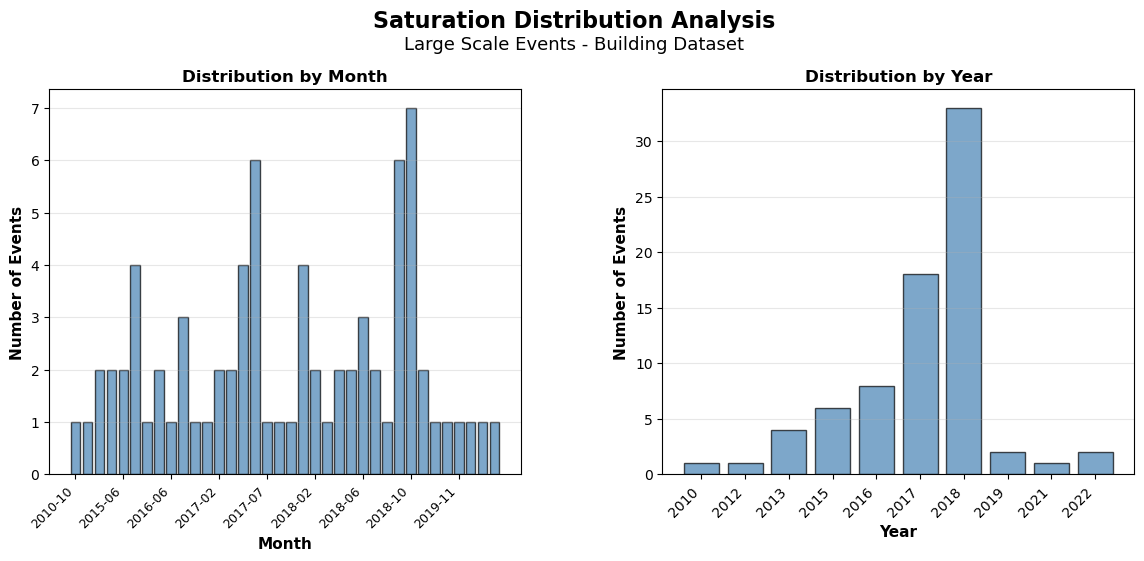

Building Events (Complete):
  Total: 76
  Earliest saturation: 2010-10-01
  Latest saturation: 2022-12-01


In [26]:
# ===== BUILDINGS BLOCK =====
fig1 = plt.figure(figsize=(14, 5))
gs1 = gridspec.GridSpec(1, 2, figure=fig1, hspace=0.3, wspace=0.3)

ax1_month = fig1.add_subplot(gs1[0, 0])
ax1_year = fig1.add_subplot(gs1[0, 1])

# Left: Histogram by month for buildings
bld_months = bld_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
bld_months_str = bld_months.index.astype(str)
ax1_month.bar(range(len(bld_months)), bld_months.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1_month.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1_month.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax1_month.set_title('Distribution by Month', fontsize=12, fontweight='bold')
ax1_month.set_xticks(range(0, len(bld_months), max(1, len(bld_months) // 8)))
ax1_month.set_xticklabels(bld_months_str[::max(1, len(bld_months) // 8)], rotation=45, ha='right', fontsize=9)
ax1_month.grid(True, alpha=0.3, axis='y')

# Right: Histogram by year for buildings
bld_years = bld_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
bld_years_str = bld_years.index.astype(str)
ax1_year.bar(range(len(bld_years)), bld_years.values, color='steelblue', alpha=0.7, edgecolor='black')
ax1_year.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1_year.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax1_year.set_title('Distribution by Year', fontsize=12, fontweight='bold')
ax1_year.set_xticks(range(len(bld_years)))
ax1_year.set_xticklabels(bld_years_str, rotation=45, ha='right')
ax1_year.grid(True, alpha=0.3, axis='y')

plt.suptitle('Saturation Distribution Analysis', fontsize=16, fontweight='bold', y=1.04)
fig1.text(0.5, 0.96, 'Large Scale Events - Building Dataset', ha='center', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Building Events (Complete):")
print(f"  Total: {len(bld_sat)}")
print(f"  Earliest saturation: {bld_sat['saturation_point'].min().date()}")
print(f"  Latest saturation: {bld_sat['saturation_point'].max().date()}")

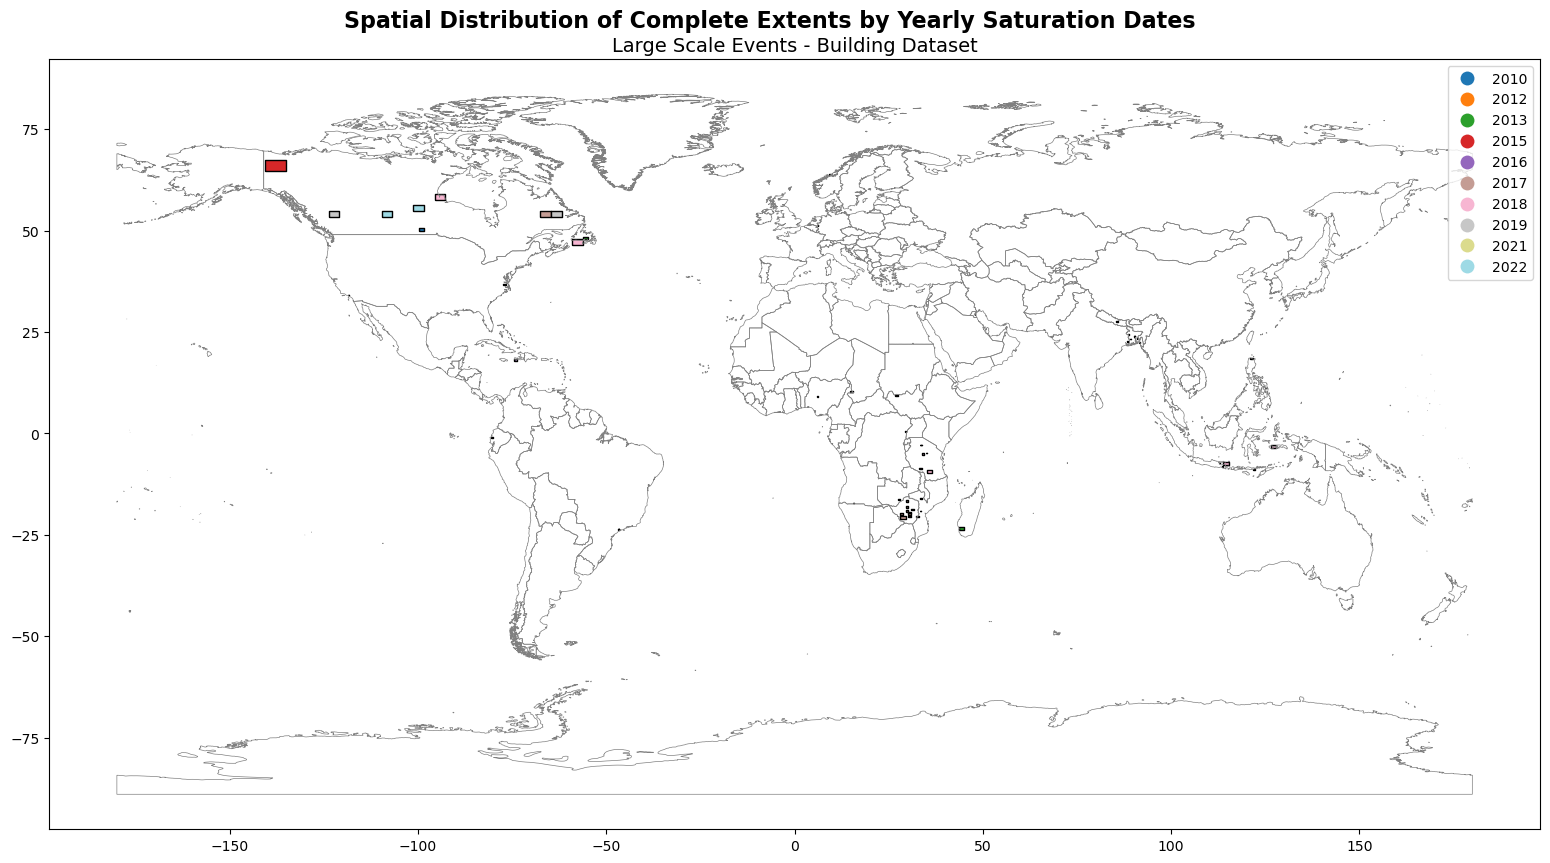

In [ ]:
# Create yearly saturation histogram map
# Quantile bins for saturation dates
complete_bld_gdf = gdf[gdf['bld_status'] == 'complete'].copy()
complete_bld_gdf['saturation_year'] = complete_bld_gdf['bld_saturation_point'].dt.year.astype(int)

# Plot the map with quantile categories
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
countries.boundary.plot(ax=ax, edgecolor='gray', linewidth=0.5)
complete_bld_gdf.plot(column='saturation_year', categorical=True, legend=True, ax=ax, cmap='tab20', edgecolor='black')
ax.set_title('Large Scale Events - Building Dataset', fontsize=14)
fig.suptitle('Spatial Distribution of Complete Extents by Yearly Saturation Dates', fontsize=16, fontweight='bold', y=0.93)
plt.show()

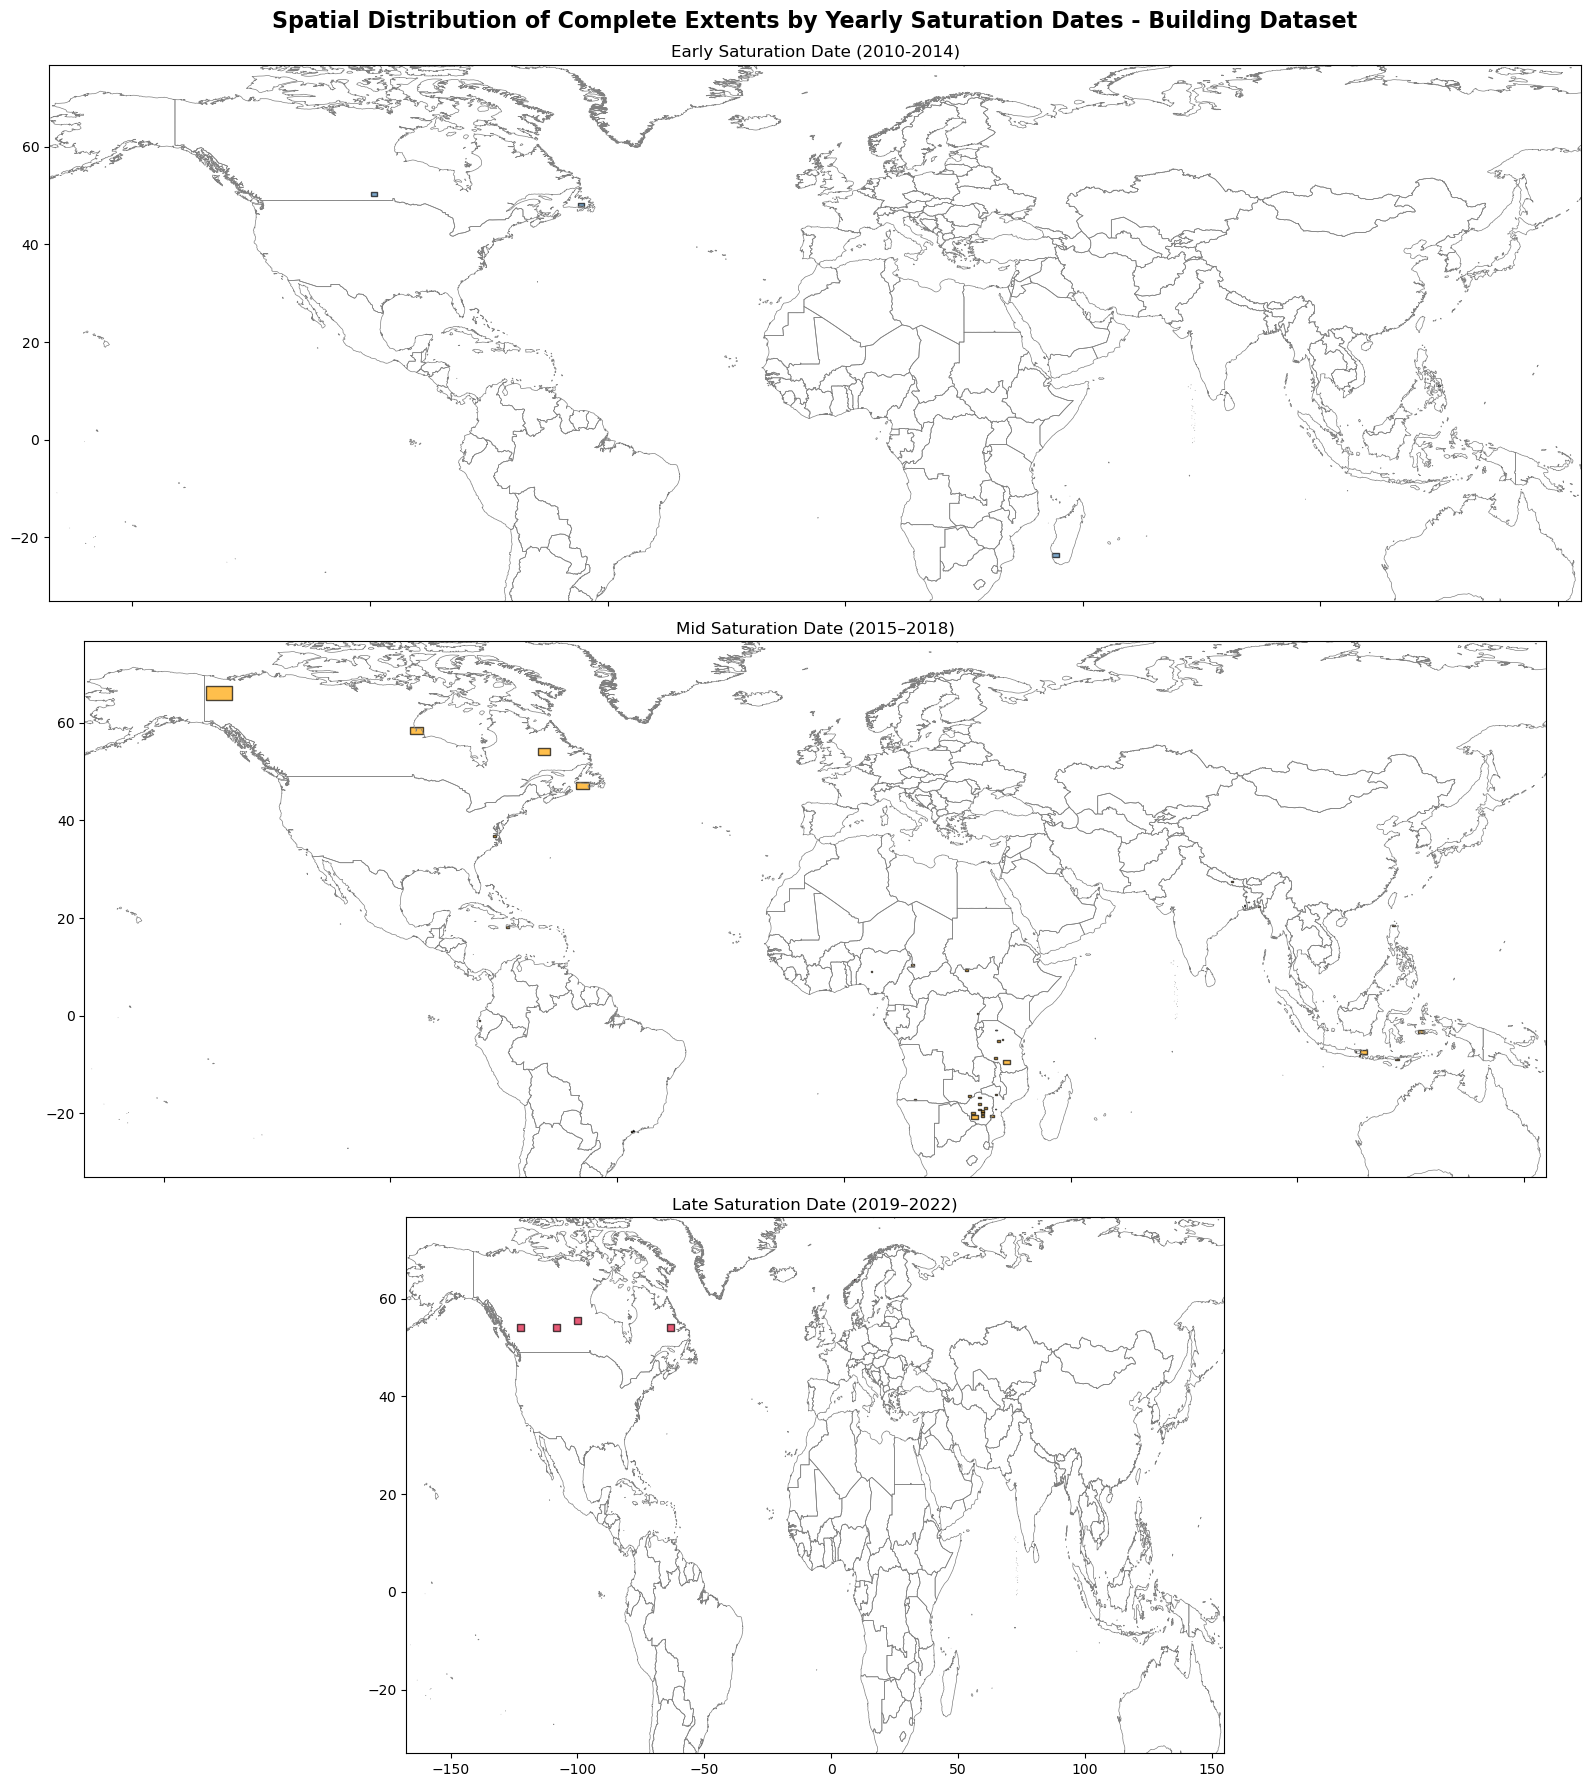

In [144]:
fig, axes = plt.subplots(3, 1, figsize=(30, 18), sharex=True, sharey=True)

# global extent (important for comparability)
minx, miny, maxx, maxy = complete_bld_gdf.total_bounds
buffer_x = (maxx - minx) * 0.1
buffer_y = (maxy - miny) * 0.1

xlim = (minx - buffer_x, maxx + buffer_x)
ylim = (miny - buffer_y, maxy + buffer_y)

# ---------------- EARLY ----------------
gdf_early = complete_bld_gdf[complete_bld_gdf['saturation_year'] <= 2014]

countries.boundary.plot(ax=axes[0], edgecolor='gray', linewidth=0.5)

gdf_early.plot(
    color="steelblue",
    ax=axes[0],
    edgecolor='black',
    alpha=0.7,
    markersize=6
)

axes[0].set_title("Early Saturation Date (2010-2014)")
axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)

# ---------------- MID ----------------
gdf_mid = complete_bld_gdf[
    (complete_bld_gdf['saturation_year'] > 2014) &
    (complete_bld_gdf['saturation_year'] <= 2018)
]

countries.boundary.plot(ax=axes[1], edgecolor='gray', linewidth=0.5)

gdf_mid.plot(
    color="orange",
    ax=axes[1],
    edgecolor='black',
    alpha=0.7,
    markersize=6
)

axes[1].set_title("Mid Saturation Date (2015–2018)")
axes[1].set_xlim(xlim)
axes[1].set_ylim(ylim)

# ---------------- LATE ----------------
gdf_late = complete_bld_gdf[complete_bld_gdf['saturation_year'] > 2018]

countries.boundary.plot(ax=axes[2], edgecolor='gray', linewidth=0.5)

gdf_late.plot(
    color="crimson",
    ax=axes[2],
    edgecolor='black',
    alpha=0.7,
    markersize=6
)

axes[2].set_title("Late Saturation Date (2019–2022)")
axes[2].set_xlim(xlim)
axes[2].set_ylim(ylim)



fig.suptitle(
    "Spatial Distribution of Complete Extents by Yearly Saturation Dates - Building Dataset",
    fontsize=16,
    fontweight='bold',
    y=0.99
)

plt.tight_layout()
plt.show()

C:\Users\eliya\AppData\Local\Temp\ipykernel_14332\425559372.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  road_months = road_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_14332\425559372.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  road_years = road_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
C:\Users\eliya\AppData\Local\Temp\ipykernel_14332\425559372.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


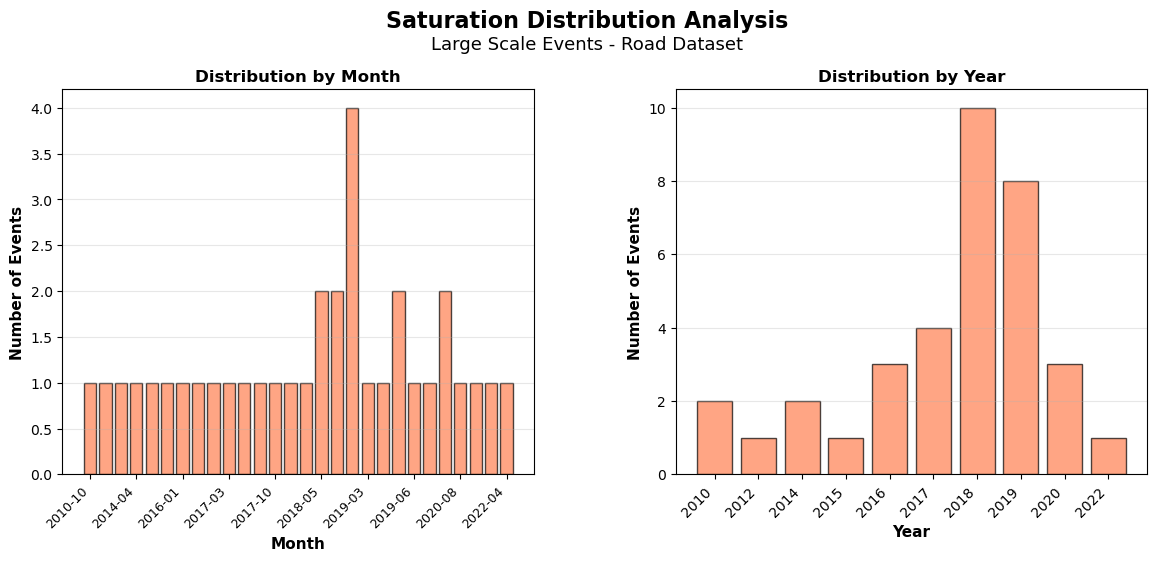


Road Events (Complete):
  Total: 35
  Earliest saturation: 2010-10-01
  Latest saturation: 2022-04-01


In [27]:
# ===== ROADS BLOCK =====
fig2 = plt.figure(figsize=(14, 5))
gs2 = gridspec.GridSpec(1, 2, figure=fig2, hspace=0.3, wspace=0.3)

ax2_month = fig2.add_subplot(gs2[0, 0])
ax2_year = fig2.add_subplot(gs2[0, 1])

# Left: Histogram by month for roads
road_months = road_sat['saturation_point'].dt.to_period('M').value_counts().sort_index()
road_months_str = road_months.index.astype(str)
ax2_month.bar(range(len(road_months)), road_months.values, color='coral', alpha=0.7, edgecolor='black')
ax2_month.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2_month.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax2_month.set_title('Distribution by Month', fontsize=12, fontweight='bold')
ax2_month.set_xticks(range(0, len(road_months), max(1, len(road_months) // 8)))
ax2_month.set_xticklabels(road_months_str[::max(1, len(road_months) // 8)], rotation=45, ha='right', fontsize=9)
ax2_month.grid(True, alpha=0.3, axis='y')

# Right: Histogram by year for roads
road_years = road_sat['saturation_point'].dt.to_period('Y').value_counts().sort_index()
road_years_str = road_years.index.astype(str)
ax2_year.bar(range(len(road_years)), road_years.values, color='coral', alpha=0.7, edgecolor='black')
ax2_year.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2_year.set_ylabel('Number of Events', fontsize=11, fontweight='bold')
ax2_year.set_title('Distribution by Year', fontsize=12, fontweight='bold')
ax2_year.set_xticks(range(len(road_years)))
ax2_year.set_xticklabels(road_years_str, rotation=45, ha='right')
ax2_year.grid(True, alpha=0.3, axis='y')

plt.suptitle('Saturation Distribution Analysis', fontsize=16, fontweight='bold', y=1.04)
fig2.text(0.5, 0.96, 'Large Scale Events - Road Dataset', ha='center', fontsize=13)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nRoad Events (Complete):")
print(f"  Total: {len(road_sat)}")
print(f"  Earliest saturation: {road_sat['saturation_point'].min().date()}")
print(f"  Latest saturation: {road_sat['saturation_point'].max().date()}")

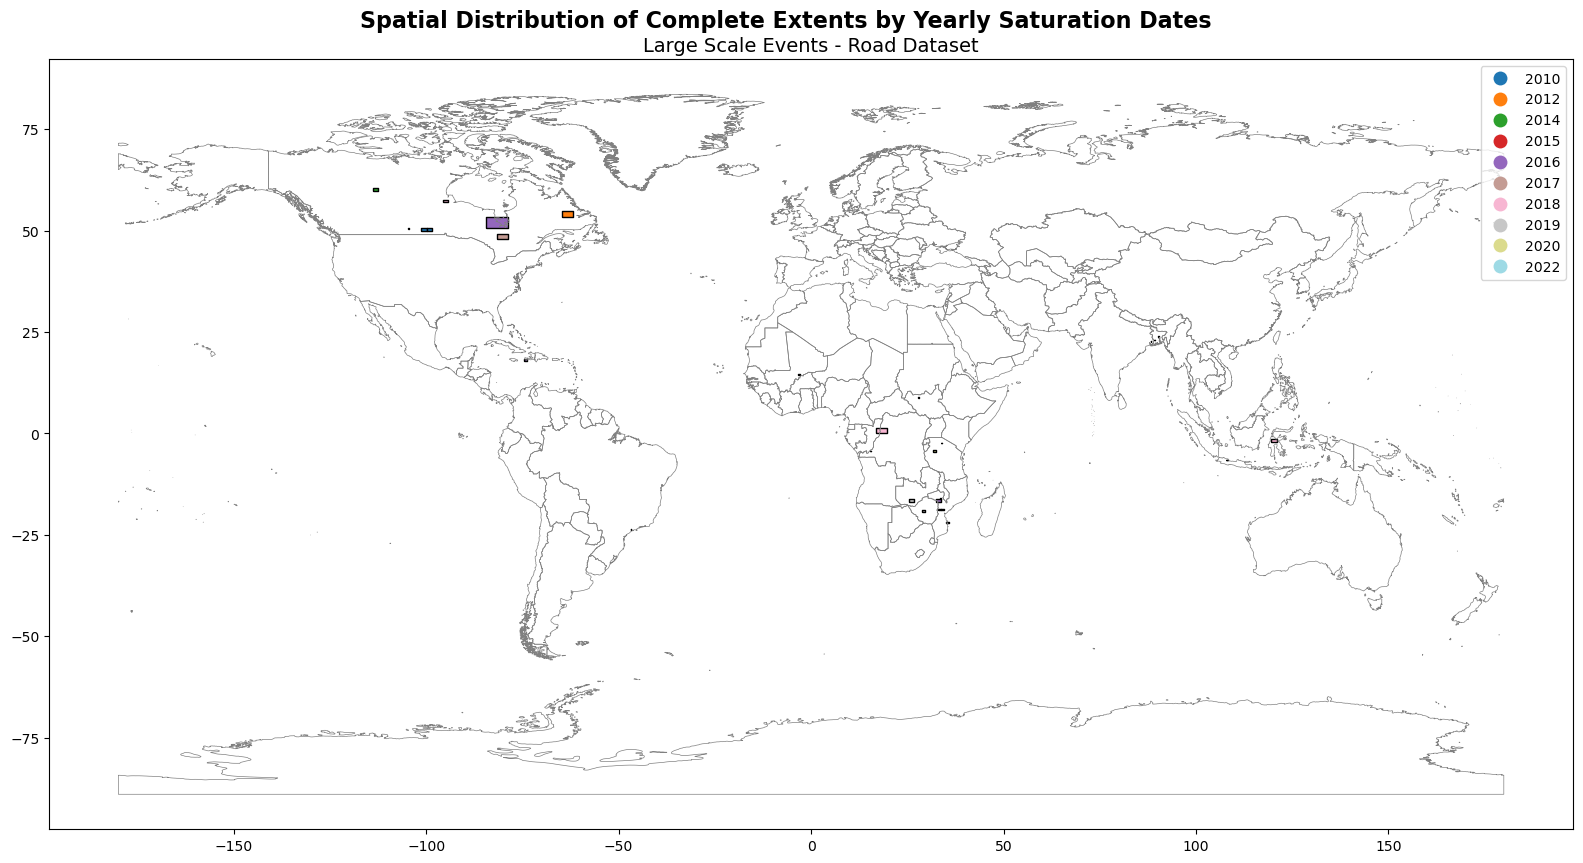

In [145]:
# Create yearly saturation histogram map
# Quantile bins for saturation dates
complete_road_gdf = gdf[gdf['road_status'] == 'complete'].copy()
complete_road_gdf['saturation_year'] = complete_road_gdf['road_saturation_point'].dt.year.astype(int)

# Plot the map with quantile categories
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
countries.boundary.plot(ax=ax, edgecolor='gray', linewidth=0.5)
complete_road_gdf.plot(column='saturation_year', categorical=True, legend=True, ax=ax, cmap='tab20', edgecolor='black')
ax.set_title('Large Scale Events - Road Dataset', fontsize=14)
fig.suptitle('Spatial Distribution of Complete Extents by Yearly Saturation Dates', fontsize=16, fontweight='bold', y=0.93)
plt.show()

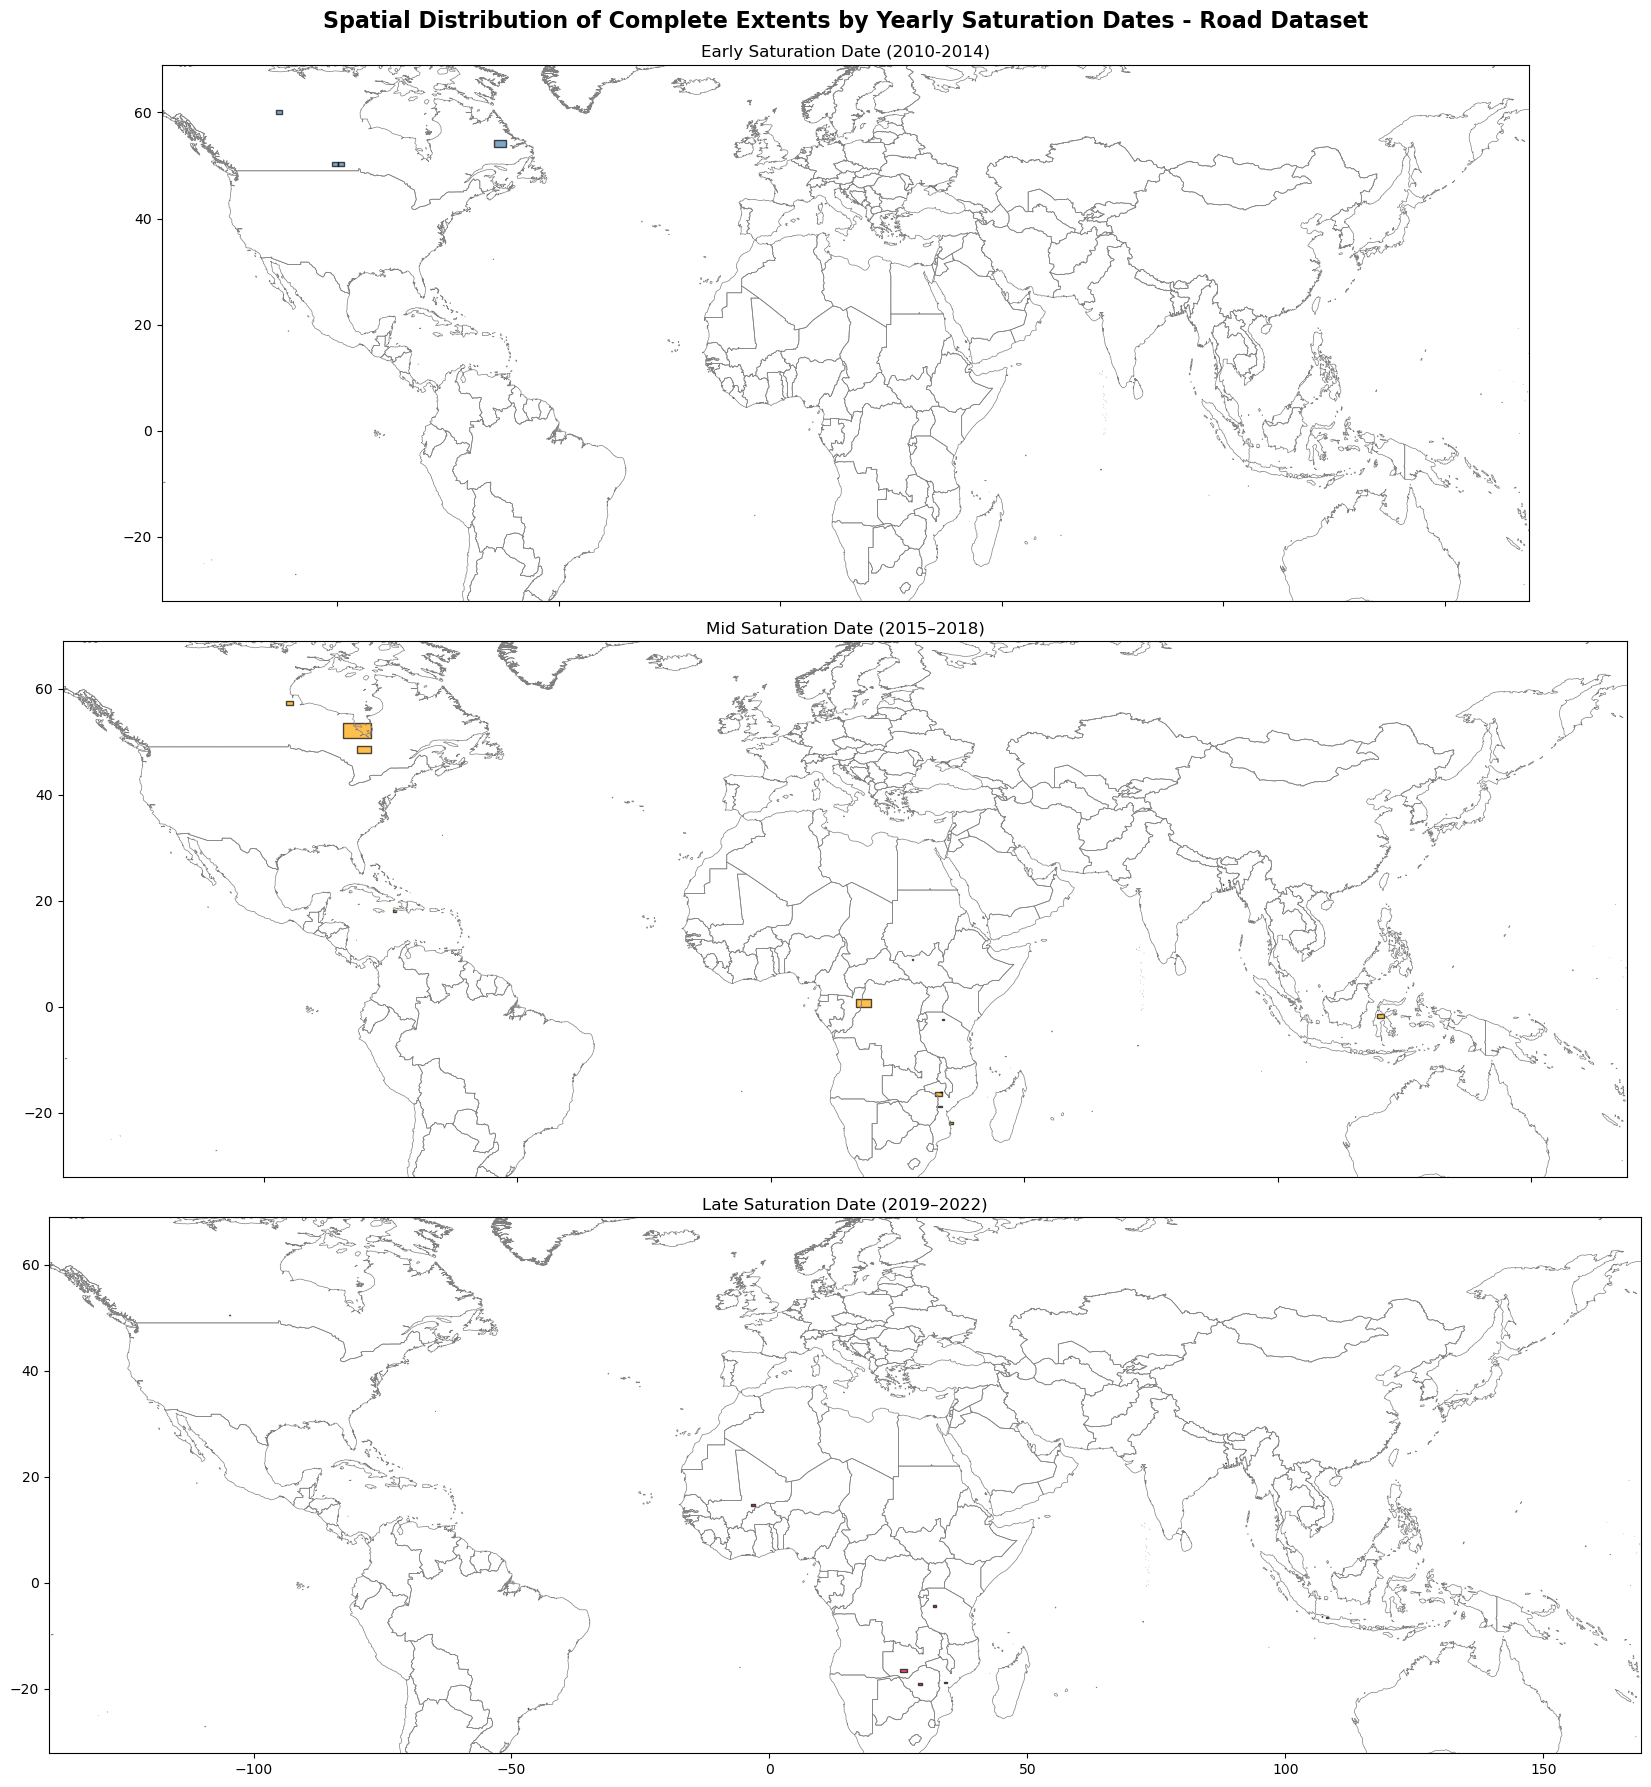

In [146]:
fig, axes = plt.subplots(3, 1, figsize=(30, 18), sharex=True, sharey=True)

# global extent (important for comparability)
minx, miny, maxx, maxy = complete_road_gdf.total_bounds
buffer_x = (maxx - minx) * 0.1
buffer_y = (maxy - miny) * 0.1

xlim = (minx - buffer_x, maxx + buffer_x)
ylim = (miny - buffer_y, maxy + buffer_y)

# ---------------- EARLY ----------------
gdf_early = complete_road_gdf[complete_road_gdf['saturation_year'] <= 2014]

countries.boundary.plot(ax=axes[0], edgecolor='gray', linewidth=0.5)

gdf_early.plot(
    color="steelblue",
    ax=axes[0],
    edgecolor='black',
    alpha=0.7,
    markersize=6
)

axes[0].set_title("Early Saturation Date (2010-2014)")
axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)

# ---------------- MID ----------------
gdf_mid = complete_road_gdf[
    (complete_road_gdf['saturation_year'] > 2014) &
    (complete_road_gdf['saturation_year'] <= 2018)
]

countries.boundary.plot(ax=axes[1], edgecolor='gray', linewidth=0.5)

gdf_mid.plot(
    color="orange",
    ax=axes[1],
    edgecolor='black',
    alpha=0.7,
    markersize=6
)

axes[1].set_title("Mid Saturation Date (2015–2018)")
axes[1].set_xlim(xlim)
axes[1].set_ylim(ylim)

# ---------------- LATE ----------------
gdf_late = complete_road_gdf[complete_road_gdf['saturation_year'] > 2018]

countries.boundary.plot(ax=axes[2], edgecolor='gray', linewidth=0.5)

gdf_late.plot(
    color="crimson",
    ax=axes[2],
    edgecolor='black',
    alpha=0.7,
    markersize=6
)

axes[2].set_title("Late Saturation Date (2019–2022)")
axes[2].set_xlim(xlim)
axes[2].set_ylim(ylim)



fig.suptitle(
    "Spatial Distribution of Complete Extents by Yearly Saturation Dates - Road Dataset",
    fontsize=16,
    fontweight='bold',
    y=0.99
)

plt.tight_layout()
plt.show()

#### Conclusions

Both datasets showed a surge in completed areas around 2018, with both having saturation values that go back as far as 2010, suggesting that the cutoff of stability combined with relative addition doesn't omit all values of areas with a long stability period, suggesting the restriction to work good.

No apparent north-south saturation temporal distribution, which is surprising and might be due to extent sizes.

### Incompletion Ratios by Reason

In [28]:
#  General bar plot of incompletion reasons by event dataset
bld_status_by_type_sum = bld_status_by_type[['Incomplete'] + reasons].sum().to_frame().T # generate general statistics for all building dataset
road_status_by_type_sum = road_status_by_type[['Incomplete'] + reasons].sum().to_frame().T # generate general statistics for all road dataset

# Calculate proportions
bld_status_by_type_sum[reasons] = round(bld_status_by_type_sum[reasons] / bld_status_by_type_sum['Incomplete'].iloc[0], 4)
road_status_by_type_sum[reasons] = round(road_status_by_type_sum[reasons] / road_status_by_type_sum['Incomplete'].iloc[0], 4)

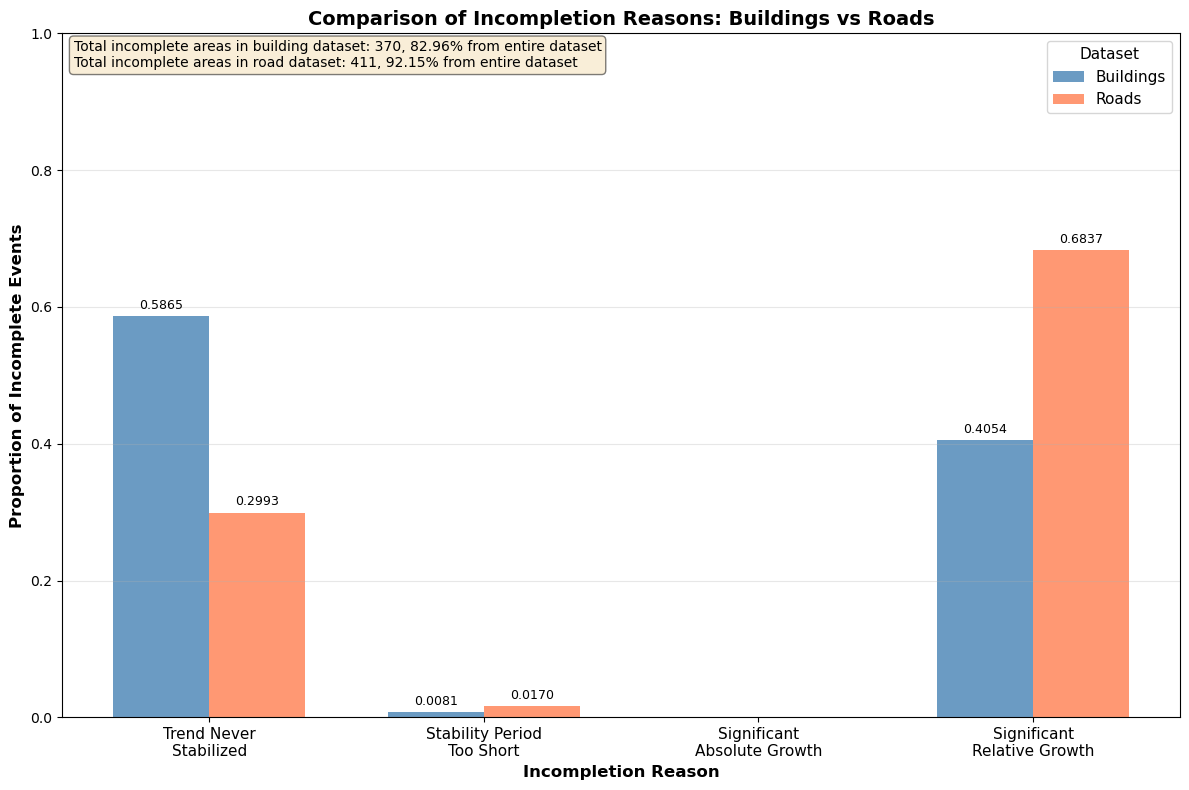

In [29]:
# Prepare data for plotting
bld_plot = bld_status_by_type_sum[reasons].iloc[0].to_frame().T.copy()
bld_plot['Data'] = 'Buildings'

road_plot = road_status_by_type_sum[reasons].iloc[0].to_frame().T.copy()
road_plot['Data'] = 'Roads'

# Combine and melt to long format
plot_data = pd.concat([bld_plot, road_plot], ignore_index=True)
plot_data = plot_data.melt(id_vars=['Data'], var_name='Reason', value_name='Proportion')

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique reasons and datasets
reasons_list = plot_data['Reason'].unique()
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(reasons_list))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_data[plot_data['Data'] == dataset]
    values = [data_subset[data_subset['Reason'] == reason]['Proportion'].values[0] if any(data_subset['Reason'] == reason) else 0 for reason in reasons_list]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Rename reasons for cleaner labels
reason_map = {
    'No stable period': 'Trend Never\nStabilized',
    'Stable relative addition': 'Significant\nRelative Growth',
    'Small stable period': 'Stability Period\nToo Short',
    'Stable absolute addition': 'Significant\nAbsolute Growth'
}

# Set labels and formatting
ax.set_xlabel('Incompletion Reason', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion of Incomplete Events', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Incompletion Reasons: Buildings vs Roads', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels([reason_map.get(r, r) for r in reasons_list], fontsize=11)
ax.legend(title='Dataset', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add incompletion counts as text label in top left
bld_incomplete = bld_status_by_type_sum['Incomplete'].iloc[0]
road_incomplete = road_status_by_type_sum['Incomplete'].iloc[0]
incompletion_text = f'Total incomplete areas in building dataset: {int(bld_incomplete)}, {int(bld_incomplete) / 446 * 100:.2f}% from entire dataset\nTotal incomplete areas in road dataset: {int(road_incomplete)}, {int(road_incomplete) / 446 * 100:.2f}% from entire dataset'

ax.text(0.01, 0.99, incompletion_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

#### Conclusions

The most popular reason that made the data be considered incomplete is significant relative growth, i.e. a stable small addition over the stability period which results in a very large relative addition over time that cannot be denied and noted as irelevant, thus implying incompletness. This is consistent with the new areas checked last week (country and region polygons).

Another reason very popular is a large addition without stabilizing, which is the first connection hypothesized to be a good proxy for incompletion.

Lastly, for all these areas, no single event occured after the possible saturation, rendering this check useless (for this dataset), and a very small prportion of areas had such a small stability period that it couldn't be considered complete using this method, strengthening it in my opinion.

###  Incompletion ratios by event typecomplete_bld_gdf['saturation_quantile'] = pd.qcut(complete_bld_gdf['bld_saturation_point'], q=5)

#### Event Type only

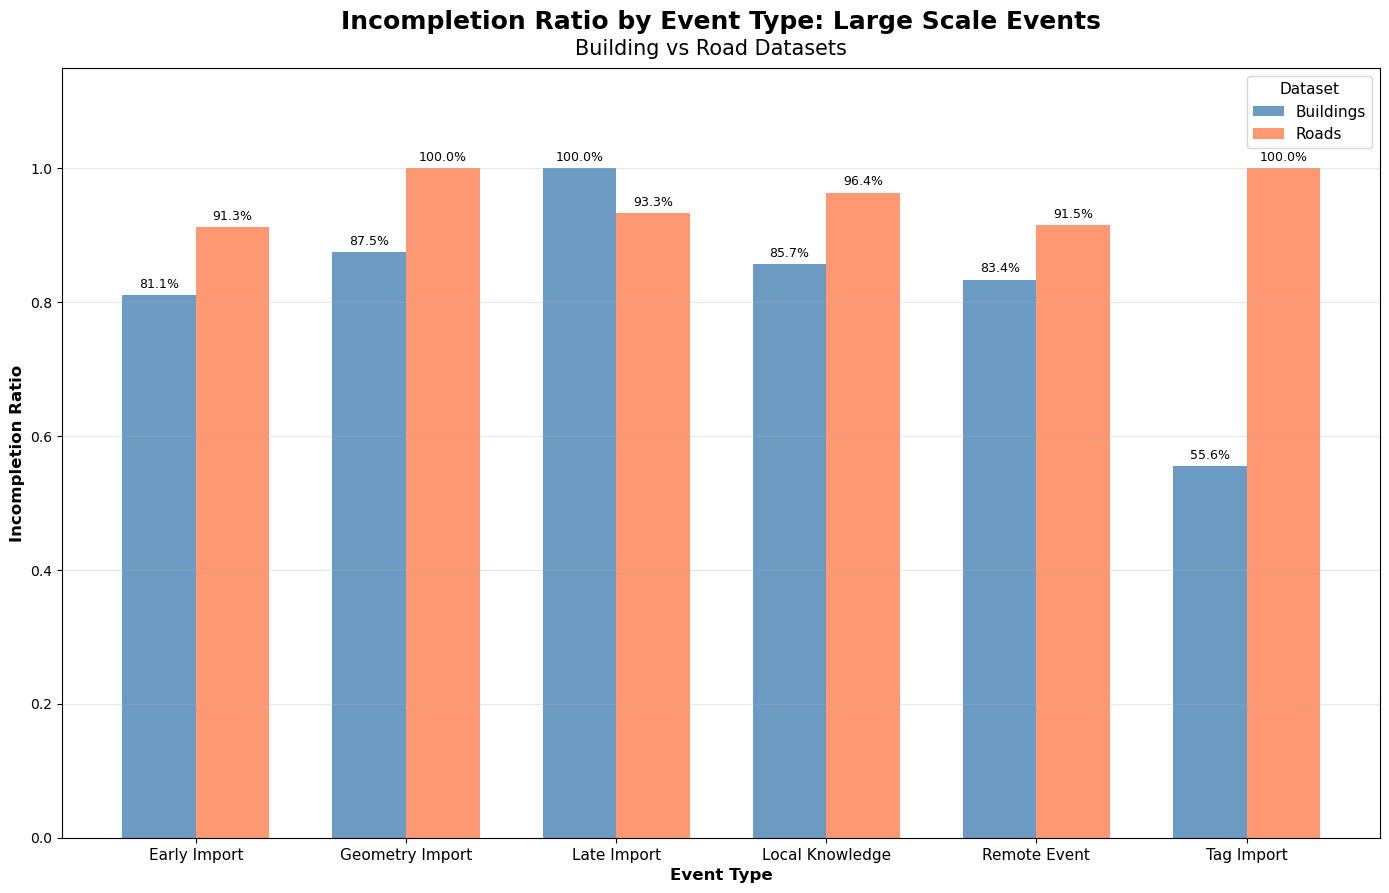

In [30]:
# Prepare data for plotting by event type
# Rename events for cleaner plot labels
bld_plot_data = bld_status_by_type.copy()
road_plot_data = road_status_by_type.copy()

bld_plot_data['Event type'] = bld_plot_data['Event type'].replace(label_map)
road_plot_data['Event type'] = road_plot_data['Event type'].replace(label_map)

# Create combined dataframe for plotting
plot_by_event = pd.concat([
    bld_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Buildings'),
    road_plot_data[['Event type', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(14, 9))

# Get unique event types
event_types = sorted(bld_plot_data['Event type'].unique())
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(event_types))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_by_event[plot_by_event['Dataset'] == dataset]
    values = [data_subset[data_subset['Event type'] == event]['Incomplete percentage'].values[0] if any(data_subset['Event type'] == event) else 0 for event in event_types]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Set labels and formatting
ax.set_xlabel('Event Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
ax.set_title('Incompletion Ratio by Event Type: Large Scale Events', 
             fontsize=18, fontweight='bold', y=1.04)
ax.text(s='Building vs Road Datasets', fontsize=15, x=2.45, y=1.17, ha='center')
ax.set_ylim(0, 1.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(event_types, fontsize=11, ha='center')
ax.legend(title='Dataset', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Conclusions

Here, we see an interesting trend, where the incompletion ratio doesn't change drastically between events, possibly showing us that the method works pretty solidly on areas with different mapping culture attributes, pointing to it being general enough (possibly) to work for other areas as well. This was contradicted last week with new data presented to it, presenting a challenge we've yet to tackle.

#### Event Type & Reason

In [31]:
# Format data in long format for plotting:

# Data extraction
bld_long = bld_status_by_type[['Event type', 'Incomplete'] + reasons].copy()
rds_long = road_status_by_type[['Event type', 'Incomplete'] + reasons].copy()

# Renaming events for cleaner plot labels
bld_long['Event type'] = bld_long['Event type'].replace(label_map)
rds_long['Event type'] = rds_long['Event type'].replace(label_map)

# Ensure matching columns for concatenation
rds_long.columns = bld_long.columns

# Normalize counts by reason to total incomplete data
bld_long[reasons] = bld_long[reasons].div(bld_long['Incomplete'], axis=0).fillna(0)
rds_long[reasons] = rds_long[reasons].div(rds_long['Incomplete'], axis=0).fillna(0)

# Add source labels
bld_long['Data'] = 'Buildings'
rds_long['Data'] = 'Roads'

# Concatenate data and convert to long format for plotting
combined = pd.concat([bld_long, rds_long], ignore_index=True)
combined = combined.melt(id_vars=['Event type', 'Data', 'Incomplete'], 
                        var_name='Reason', 
                        value_name='Proportion')

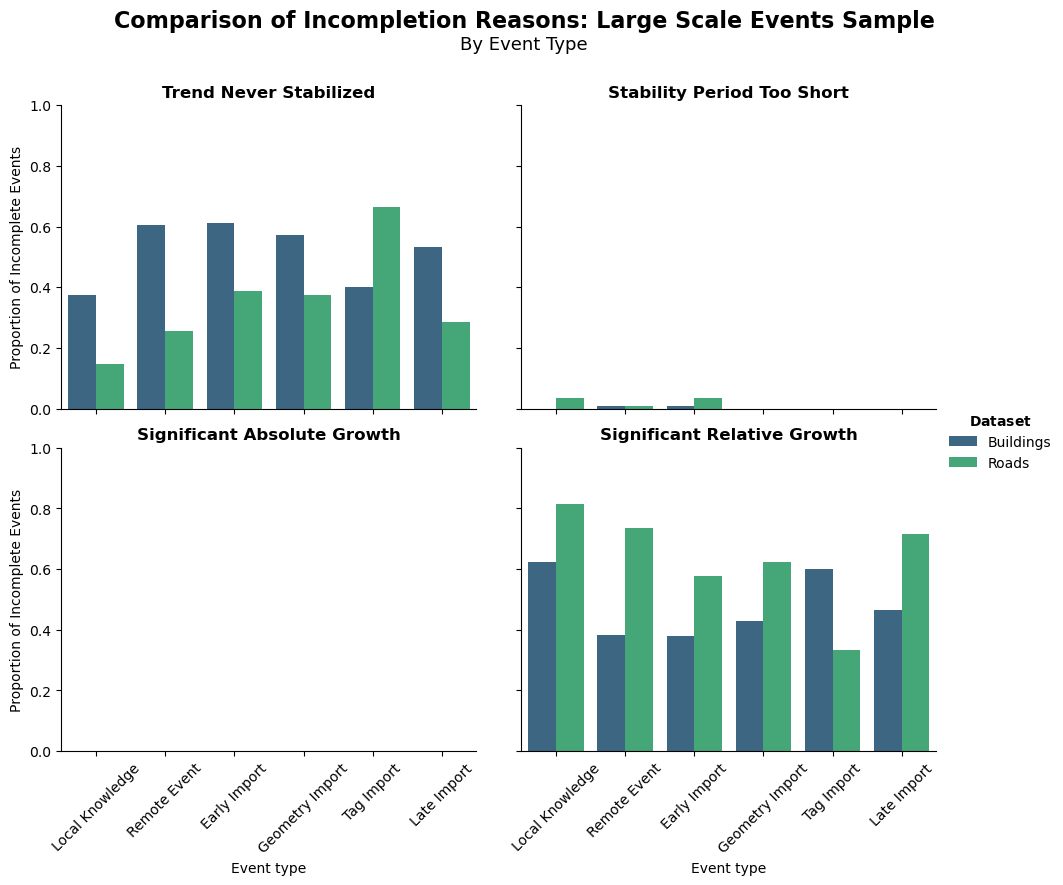

In [32]:
# Create a plot of the results
reason_map = {
    'No stable period': 'Trend Never Stabilized',
    'Small stable period': 'Stability Period Too Short',
    'Stable absolute addition': 'Significant Absolute Growth',
    'Stable relative addition': 'Significant Relative Growth'
}

g = sns.catplot(
    data=combined, 
    kind="bar",
    x="Event type", 
    y="Proportion",
    hue="Data",
    col="Reason",
    col_wrap=2,
    palette="viridis",
    height=4,
    aspect=1.2
)

g.set(ylim=(0, 1)) # Fix y axis limits to 0-100% for better comparison
g.set_titles(col_template="{col_name}", fontweight='bold') # Set column titles

# Set Y-axis to percentage format for clarity
for ax in g.axes.flat:
    # Get the current title
    current_title = ax.get_title().split('= ')[-1]
    # Map to new name and make bold
    new_title = reason_map.get(current_title, current_title)
    ax.set_title(new_title, fontweight='bold', fontsize=12)
    
    # Label the X-axis
    ax.tick_params(axis='x', labelrotation=45)
    
    # Label the Y-axis
    ax.set_ylabel("Proportion of Incomplete Events")

# Adjust legend title
g._legend.set_title(r"$\bf{Dataset}$")

# Add general title
plt.subplots_adjust(top=0.88) # Make room for the suptitle
g.fig.suptitle('Comparison of Incompletion Reasons: Large Scale Events Sample', 
               fontsize=16, fontweight='bold', y=1)
g.fig.text(0.5, 0.95, 'By Event Type',
           ha='center', fontsize=13)

plt.show()

#### Conclusions

When looking at the trends more closely, we can see charcteristics of events incomplete mapping in roads according to the method. If it's correct, this means that it might help decipher different mapping results, such as the fact that tag import events had more incomplete areas due to no stability period, as opposed to ocal knowledge due mostly to a significant relative growth. 

This means that if we assume the method works well, it uncovers different incomplete mapping results according to mapping culture attributes, which can be a very interesting discovery.

### By extent (bbox) size

#### Calculate area per each event polygon

In [40]:
gdf.to_crs(epsg=8857, inplace=True) # change crs to WGS84 / equal earth for accurate metric area calculation

In [ ]:
gdf['area'] = gdf['geometry'].area # calculate area in square meters for each grid cell

#### Append to test data

In [92]:
# Create a string-keyed area lookup from gdf
area_lookup = {str(bbox): area for bbox, area in zip(gdf['bbox'], gdf['area'])}

# Apply rowwise lookup
bld_tests = [{**row, 'area': area_lookup.get(str(row['bbox']), np.nan)} for row in bld_tests]
road_tests = [{**row, 'area': area_lookup.get(str(row['bbox']), np.nan)} for row in road_tests]

In [93]:
# Create simple DF for analysis
road_status_by_area = pd.DataFrame(road_tests)[['area', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type']].copy()
bld_status_by_area = pd.DataFrame(bld_tests)[['area', 'status', 'saturation_point', 'incompletion_reason', 'idx', 'event_type']].copy()

In [94]:
# Convert area to square kilometers for easier interpretation
road_status_by_area['area_sqkm'] = round(road_status_by_area['area'] / 1000, 3)
bld_status_by_area['area_sqkm'] = round(bld_status_by_area['area'] / 1000, 3)

In [95]:
# Explanation snippet for filtering:
std = round(np.var(road_status_by_area['area_sqkm'])**0.5, 2)

display(Markdown(f"""
Because the variance of the area values is so big ($\\sigma = {std}$), 
we'll filter out outliers from the datasets.
"""))


Because the variance of the area values is so big ($\sigma = 73406558.41$), 
we'll filter out outliers from the datasets.


In [96]:
# Filtering out the data
Q1 = road_status_by_area['area_sqkm'].quantile(0.25)
Q3 = road_status_by_area['area_sqkm'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 2 * IQR
upper = Q3 + 2 * IQR

# Filter outliers out
filtered_road_status_by_area = road_status_by_area[
    (road_status_by_area['area_sqkm'] >= lower) & 
    (road_status_by_area['area_sqkm'] <= upper)
]

filtered_bld_status_by_area = bld_status_by_area[
    (bld_status_by_area['area_sqkm'] >= lower) & 
    (bld_status_by_area['area_sqkm'] <= upper)
]

# Print new data shapes:
print('Original datasets\nRoads:')
print(f"  Shape: {road_status_by_area.shape}")
print(f"  No. of complete features: {road_status_by_area[road_status_by_area['status'] == 'complete'].shape[0]}")
print('Buildings:')
print(f"  Shape: {bld_status_by_area.shape}")
print(f"No. of complete features: {bld_status_by_area[bld_status_by_area['status'] == 'complete'].shape[0]}\n")

print('Filtered datasets\nRoads:')
print(f"  Shape: {filtered_road_status_by_area.shape}")
print(f"  No. of complete features: {filtered_road_status_by_area[filtered_road_status_by_area['status'] == 'complete'].shape[0]}")
print('Buildings:')
print(f"  Shape: {filtered_bld_status_by_area.shape}")
print(f"  No. of complete features: {filtered_bld_status_by_area[filtered_bld_status_by_area['status'] == 'complete'].shape[0]}\n")

Original datasets
Roads:
  Shape: (446, 7)
  No. of complete features: 35
Buildings:
  Shape: (446, 7)
No. of complete features: 76

Filtered datasets
Roads:
  Shape: (381, 7)
  No. of complete features: 31
Buildings:
  Shape: (381, 7)
  No. of complete features: 68



Note: because using the formula of $1.5 \times IQR$ amounted to removing a quarter of the data (about 100 entries were considered outliers) I decided to be less constrictive and regard only entries which are beyond the benchmark of  $2 \times IQR$ - that, while they amount to a quarter of the data..

#### General Distribution of areas

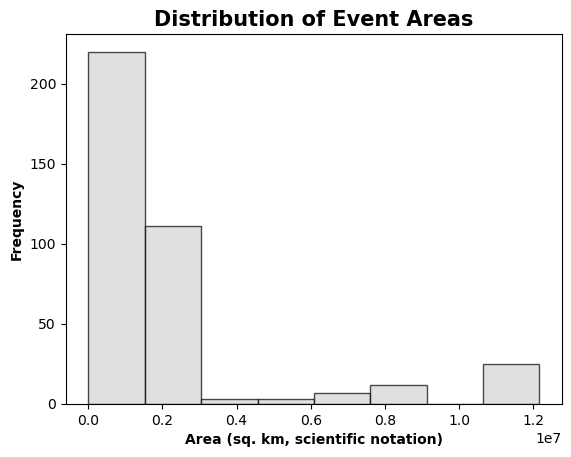

Minimum area: 7924.186
Maximum area: 12165114.694


In [174]:
filtered_road_status_by_area['area_sqkm'].plot.hist(
    bins=8, 
    color='lightgrey', 
    alpha=0.7, 
    edgecolor='black')
plt.xlabel('Area (sq. km, scientific notation)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Event Areas', fontsize=15, fontweight='bold')
plt.show()

print(f'Minimum area: {filtered_road_status_by_area["area_sqkm"].min()}')
print(f'Maximum area: {filtered_road_status_by_area["area_sqkm"].max()}')

We can see the variation of area with the large gap and bin width above.

#### Distribution of Incompletion by area bins

In [98]:
# Bin the area values into 8 equal-width bins for further analysis
filtered_road_status_by_area = filtered_road_status_by_area.copy()
filtered_road_status_by_area['area_bin'] = pd.cut(filtered_road_status_by_area['area_sqkm'], bins=8)

filtered_bld_status_by_area = filtered_bld_status_by_area.copy()
filtered_bld_status_by_area['area_bin'] = pd.cut(filtered_bld_status_by_area['area_sqkm'], bins=8)

In [99]:
# Generate completion statistics by area bin
filtered_road_sum_by_area = filtered_road_status_by_area.groupby('area_bin', observed=True).agg(
    Complete=('status', lambda x: (x == 'complete').sum()),
    Incomplete=('status', lambda x: (x == 'incomplete').sum()),
    Sample_size=('area_sqkm', 'count'),
    complete_percentage=('status', lambda x: (x == 'complete').mean().round(3)),
    incomplete_percentage=('status', lambda x: (x == 'incomplete').mean().round(3)),
    no_stable_period=('incompletion_reason', lambda x: (x == 'no stable period').sum()),
    small_stable_period=('incompletion_reason', lambda x: (x == 'stable period shorter than threshold').sum()),
    stable_absolute_addition=('incompletion_reason', lambda x: (x == 'stable absolute addition larger than threshold').sum()),
    stable_relative_addition=('incompletion_reason', lambda x: (x == 'stable relative addition larger than threshold').sum())
).reset_index()

filtered_road_sum_by_area.rename(columns={
    'area_bin': 'Area bin',
    'Sample_size': 'Sample size (n)',
    'complete_percentage': 'Complete percentage',
    'incomplete_percentage': 'Incomplete percentage',
    'no_stable_period': 'No stable period',
    'small_stable_period': 'Small stable period',
    'stable_absolute_addition': 'Stable absolute addition',
    'stable_relative_addition': 'Stable relative addition'
}, inplace=True)

In [100]:
# Generate completion statistics by area bin
filtered_bld_sum_by_area = filtered_bld_status_by_area.groupby('area_bin', observed=True).agg(
    Complete=('status', lambda x: (x == 'complete').sum()),
    Incomplete=('status', lambda x: (x == 'incomplete').sum()),
    Sample_size=('area_sqkm', 'count'),
    complete_percentage=('status', lambda x: (x == 'complete').mean().round(3)),
    incomplete_percentage=('status', lambda x: (x == 'incomplete').mean().round(3)),
    no_stable_period=('incompletion_reason', lambda x: (x == 'no stable period').sum()),
    small_stable_period=('incompletion_reason', lambda x: (x == 'stable period shorter than threshold').sum()),
    stable_absolute_addition=('incompletion_reason', lambda x: (x == 'stable absolute addition larger than threshold').sum()),
    stable_relative_addition=('incompletion_reason', lambda x: (x == 'stable relative addition larger than threshold').sum())
).reset_index()

filtered_bld_sum_by_area.rename(columns={
    'area_bin': 'Area bin',
    'Sample_size': 'Sample size (n)',
    'complete_percentage': 'Complete percentage',
    'incomplete_percentage': 'Incomplete percentage',
    'no_stable_period': 'No stable period',
    'small_stable_period': 'Small stable period',
    'stable_absolute_addition': 'Stable absolute addition',
    'stable_relative_addition': 'Stable relative addition'
}, inplace=True)

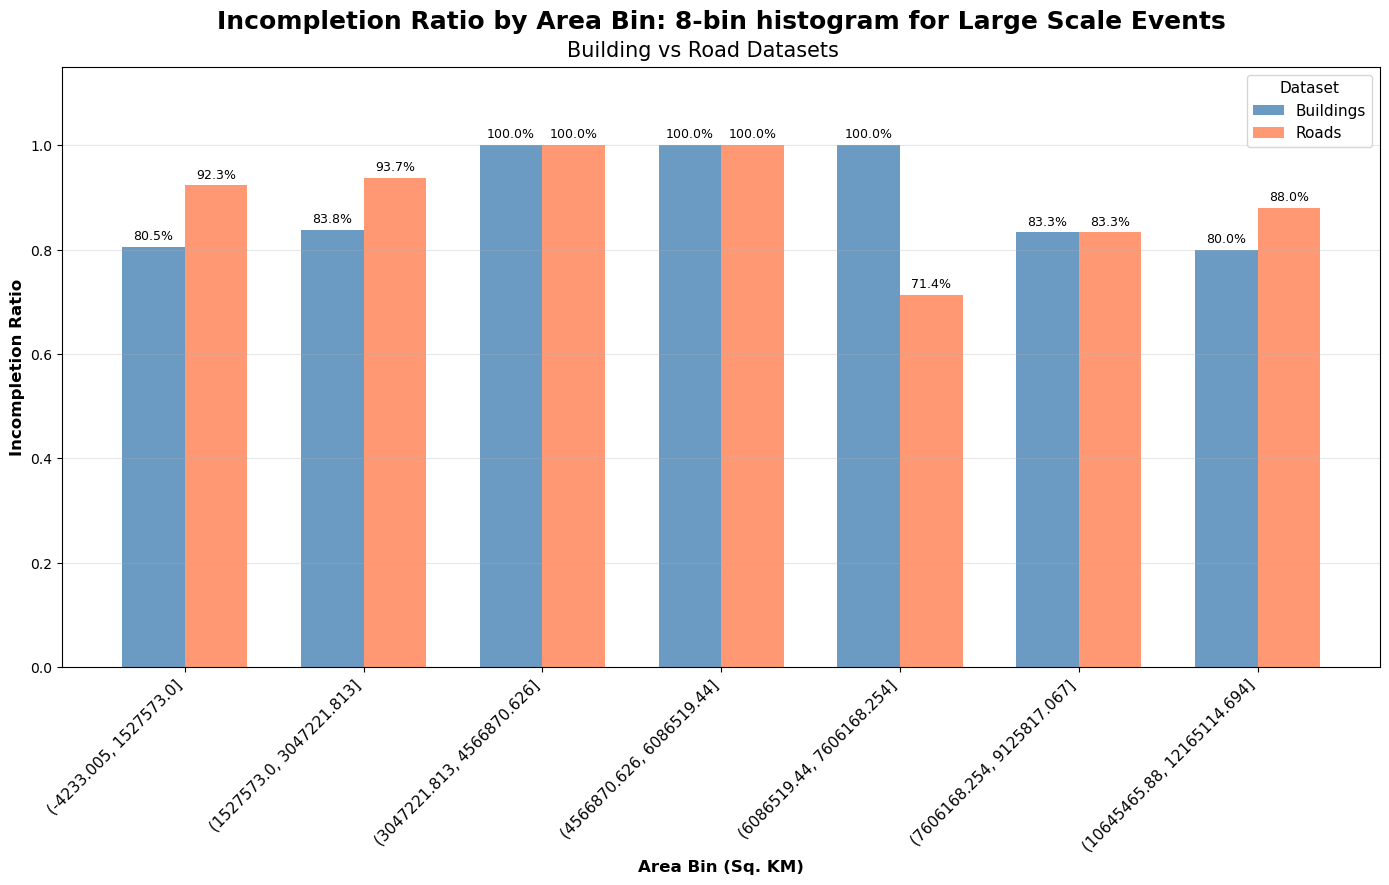

In [171]:
# Prepare data for plotting by event type
# Create combined dataframe for plotting
plot_by_area = pd.concat([
    filtered_bld_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Buildings'),
    filtered_road_sum_by_area[['Area bin', 'Incomplete percentage']].assign(Dataset='Roads')
], ignore_index=True)

# Create histogram-style bar plot
fig, ax = plt.subplots(figsize=(14, 9))

# Get unique area bins
area_bins = sorted(filtered_bld_sum_by_area['Area bin'].unique())
datasets = ['Buildings', 'Roads']
bar_width = 0.35
x_pos = np.arange(len(area_bins))

# Create bars for each dataset
colors = ['steelblue', 'coral']
for i, dataset in enumerate(datasets):
    data_subset = plot_by_area[plot_by_area['Dataset'] == dataset]
    values = [data_subset[data_subset['Area bin'] == bin]['Incomplete percentage'].values[0] if any(data_subset['Area bin'] == bin) else 0 for bin in area_bins]
    offset = (i - 0.5) * bar_width
    bars = ax.bar(x_pos + offset, values, bar_width, label=dataset, alpha=0.8, color=colors[i])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Set labels and formatting
ax.set_xlabel('Area Bin (Sq. KM)', fontsize=12, fontweight='bold')
ax.set_ylabel('Incompletion Ratio', fontsize=12, fontweight='bold')
ax.set_title('Incompletion Ratio by Area Bin:\nBuilding vs Road Datasets', 
             fontsize=18, fontweight='bold')
ax.set_title('Incompletion Ratio by Area Bin: 8-bin histogram for Large Scale Events', 
             fontsize=18, fontweight='bold', y=1.05)
ax.text(s='Building vs Road Datasets', fontsize=15, x=2.9, y=1.17, ha='center')
ax.set_ylim(0, 1.15)
ax.set_xticks(x_pos)
ax.set_xticklabels(area_bins, fontsize=11, rotation=45, ha='right')
ax.legend(title='Dataset', fontsize=11, title_fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

##### Conclusions

There doesn't seem to be a major difference for different extent sizes..

#### Distribution of Incompletion by area bins & Incompletion reason

In [102]:
# Format data in long format for plotting:

# Data extraction
bld_long = filtered_bld_sum_by_area[['Area bin', 'Incomplete'] + reasons].copy()
rds_long = filtered_road_sum_by_area[['Area bin', 'Incomplete'] + reasons].copy()

# Ensure matching columns for concatenation
rds_long.columns = bld_long.columns

# Normalize counts by reason to total incomplete data
bld_long[reasons] = bld_long[reasons].div(bld_long['Incomplete'], axis=0).fillna(0)
rds_long[reasons] = rds_long[reasons].div(rds_long['Incomplete'], axis=0).fillna(0)

# Add source labels
bld_long['Data'] = 'Buildings'
rds_long['Data'] = 'Roads'

# Concatenate data and convert to long format for plotting
combined = pd.concat([bld_long, rds_long], ignore_index=True)
combined = combined.melt(id_vars=['Area bin', 'Data', 'Incomplete'], 
                        var_name='Reason', 
                        value_name='Proportion')

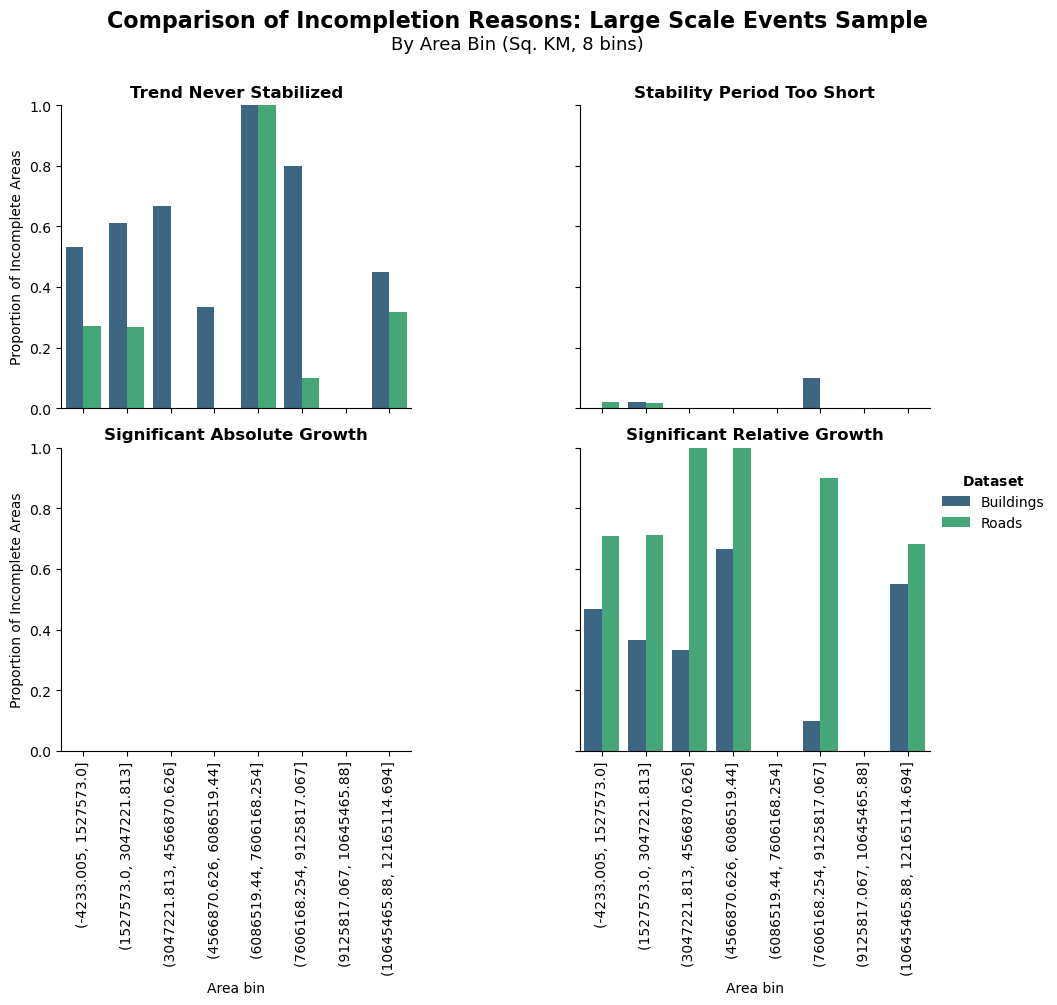

In [103]:
# Create a plot of the results
reason_map = {
    'No stable period': 'Trend Never Stabilized',
    'Small stable period': 'Stability Period Too Short',
    'Stable absolute addition': 'Significant Absolute Growth',
    'Stable relative addition': 'Significant Relative Growth'
}

g = sns.catplot(
    data=combined, 
    kind="bar",
    x="Area bin", 
    y="Proportion",
    hue="Data",
    col="Reason",
    col_wrap=2,
    palette="viridis",
    height=4,
    aspect=1.2
)

g.set(ylim=(0, 1)) # Fix y axis limits to 0-100% for better comparison
g.set_titles(col_template="{col_name}", fontweight='bold') # Set column titles

# Set Y-axis to percentage format for clarity
for ax in g.axes.flat:
    # Get the current title
    current_title = ax.get_title().split('= ')[-1]
    # Map to new name and make bold
    new_title = reason_map.get(current_title, current_title)
    ax.set_title(new_title, fontweight='bold', fontsize=12)
    
    # Label the X-axis
    ax.tick_params(axis='x', labelrotation=90)
    
    # Label the Y-axis
    ax.set_ylabel("Proportion of Incomplete Areas")

# Adjust legend title
g._legend.set_title(r"$\bf{Dataset}$")

# Add general title
plt.subplots_adjust(top=0.88) # Make room for the suptitle
g.fig.suptitle('Comparison of Incompletion Reasons: Large Scale Events Sample', 
               fontsize=16, fontweight='bold', y=1)
g.fig.text(0.5, 0.95, 'By Area Bin (Sq. KM, 8 bins)',
           ha='center', fontsize=13)

plt.show()

##### Conclusions

We can see that roads tend to have more incompletion because of significant relative growth, when buildings are more because of a non-stabilized trend, but there doesn't seem to be some noticeable change according to size - perhaps building datasets in larger areas tend to be more complete, but it doesn't seem visually significant enough.